Dictionary learning, the first attempt at explaining a 3d kernel.  

Well its kinda working finally. lasso_cd + using 75 percentile of contribs is working right now.  
I need to see if we can get to 50 percentile.  Not sure, might be worth simply going down one by one.  
Im retaining sparsity now, quite good.   

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
import os
import sys
import django

# Setup Django environment
# Adjust the path to point to the directory containing manage.py
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../hiccup_ide")))
os.environ.setdefault("DJANGO_SETTINGS_MODULE", "hiccup_ide.settings")
os.environ["DJANGO_ALLOW_ASYNC_UNSAFE"] = "true"
django.setup()

In [3]:
from neural_data.models import *
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import random
import torch
from pt_to_api.utils import show_single_channel_red_green_black as S, to_show_list as tsl
from tqdm import tqdm
from pt_to_api.contribs.v1 import show_input_patch_and_kernel_placement_for_poi_using_raw_params as SIP
import seaborn as sns
import numpy as np
from sklearn.decomposition import MiniBatchDictionaryLearning, DictionaryLearning
from sklearn.preprocessing import Normalizer
from sklearn.metrics.pairwise import pairwise_distances, cosine_similarity, cosine_distances
from scipy.optimize import linear_sum_assignment
import pandas as pd


I've checked out (2,3) in a horizontal 2d slice in {layers.2,ch12,i6}.  
Lets do (2,3) in {layers.2,ch12} itself

In [4]:
KERNEL_COORDINATE = "layers.2.out_12"
INPUT_LAYER_NAME = "layers.1"
R = 2
C = 3
MODE = "light"

In [25]:
import itertools
def scatter_plot_1d(numbers, suff=""):
    # 2. Create the visualization
    plt.figure(figsize=(20, 3))
    sns.stripplot(x=numbers, color='blue', alpha=0.5, jitter=True)

    plt.title('1D Clustering Visualization' + suff)
    plt.xlabel('Value')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()


def show_72_list(xs, **kwargs):
    res = list(itertools.chain.from_iterable([tsl(x.reshape(8,3,3)) for x in xs]))
    S(res, (20, 4*len(xs)), 8, **kwargs)
    plt.show()

def show_72(x, **kwargs):
    S(tsl(x.reshape(8,3,3)), 20, 8, **kwargs)
    plt.show()

def get_receptive(y, x, ksize=3, stride=2, padding=1):
    ys = y*stride - padding
    xs = x*stride - padding
    return (ys, xs), (ys+ksize, xs+ksize)

In [6]:
Input.objects.filter(alias__startswith="4-").count()

5056

In [7]:
weight_objs = list(Weight.objects.filter(coordinate__startswith=KERNEL_COORDINATE, data_type="weights"))

[w.coordinate for w in weight_objs]

['layers.2.out_12.in_0',
 'layers.2.out_12.in_1',
 'layers.2.out_12.in_2',
 'layers.2.out_12.in_3',
 'layers.2.out_12.in_4',
 'layers.2.out_12.in_5',
 'layers.2.out_12.in_6',
 'layers.2.out_12.in_7']

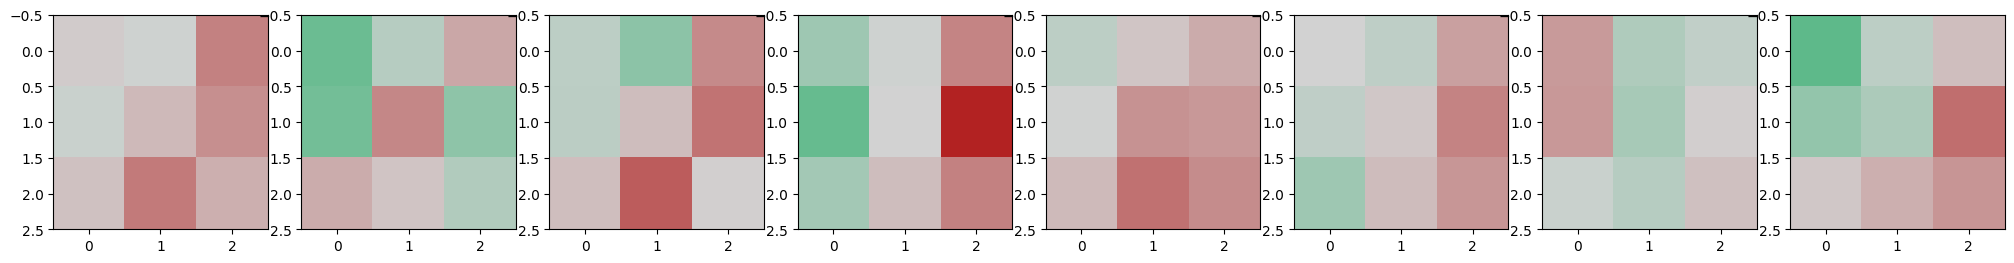

In [8]:
kernel = np.stack([w.data for w in weight_objs])
S(tsl(kernel), (20,5), 8, mode=MODE)
plt.show()

# Analyse (2,3) high contribs

100%|██████████| 5502/5502 [00:00<00:00, 941306.11it/s]


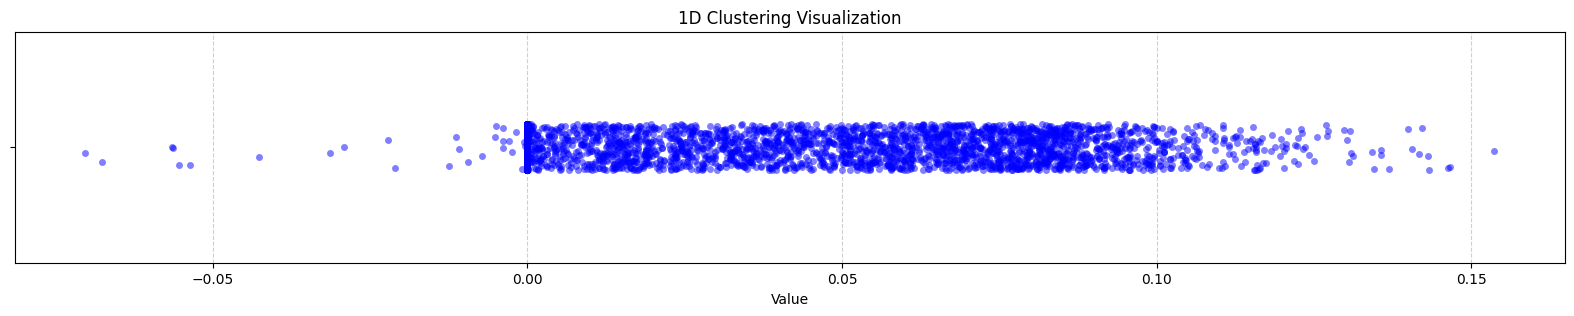

In [9]:
vals = []
for sm in tqdm(SaliencyMap.objects.filter(coordinate=KERNEL_COORDINATE)):
    vals.append(sm.data[R][C])

# well its actually quite dense
# and im not sure what the cutoff is lol
# scatter_plot_1d([v for v in vals if v > 0.02 and v < 0.05])
scatter_plot_1d(vals)

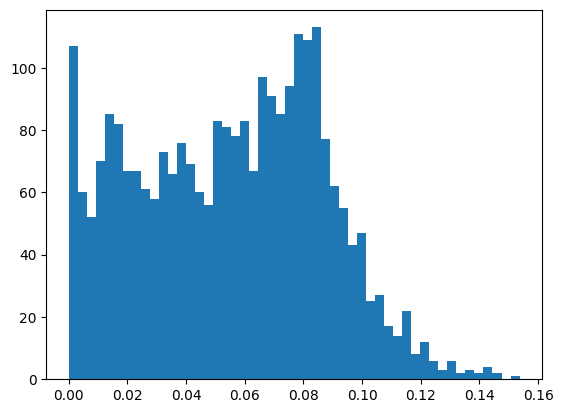

In [10]:
# although negatives are important too :) lets check them out later
# the space of those activations is quite small anyways
plt.hist([v for v in vals if v > 0], bins=50)
plt.show()

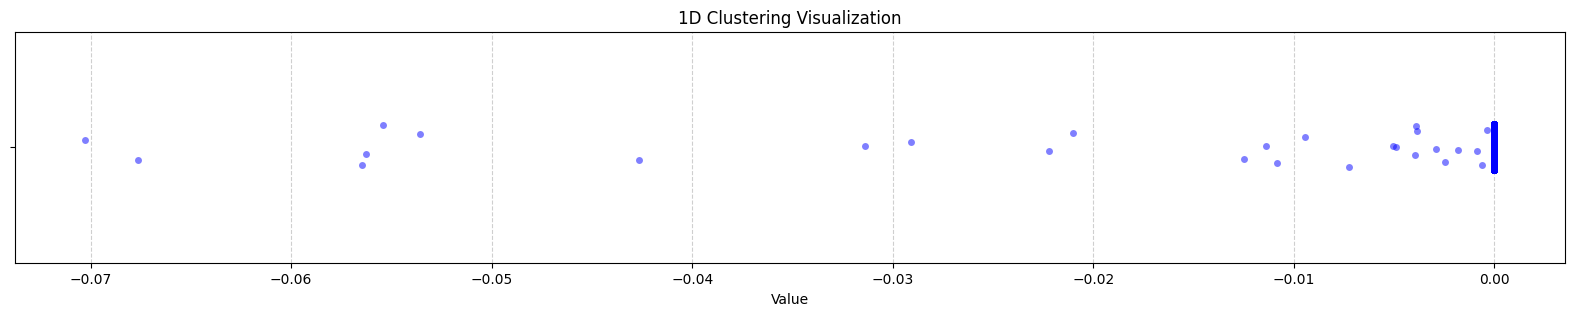

In [11]:
scatter_plot_1d([v for v in vals if v < 0])

In [12]:
# what i guess would be useful is to start from a higher value, and keep going down until we see problematic loss
pvals = [v for v in vals if v > 0]
np.mean(pvals), np.percentile(pvals, 50), np.percentile(pvals, 75), np.percentile(pvals, 60), len(pvals)

(np.float64(0.055100844846643515),
 np.float64(0.05754715949296951),
 np.float64(0.07994135841727257),
 np.float64(0.06710866093635559),
 2639)

In [13]:
# there are a significant number of negatives, but they are greater than -0.01 (almost all of them are quite near 0), essentially 0
len([v for v in vals if v == 0]), len(vals), len(pvals)

(0, 5502, 2639)

In [14]:
# lets start above mean for now
# this might be too high but nvm

POS_THRES = 0.1
POS_THRES

0.1

In [15]:
set(Activation.objects.filter(coordinate__startswith=INPUT_LAYER_NAME).order_by("coordinate").values_list("coordinate", flat=True))

{'layers.1.out_0',
 'layers.1.out_1',
 'layers.1.out_2',
 'layers.1.out_3',
 'layers.1.out_4',
 'layers.1.out_5',
 'layers.1.out_6',
 'layers.1.out_7'}

In [16]:
(y0,x0), (y1,x1) = get_receptive(R, C, 3, 2, 1)
sm_ids = []
patches = []

for sm in tqdm(SaliencyMap.objects.filter(coordinate=KERNEL_COORDINATE)):
    # act = Activation.objects.get(input=sm.input, coordinate=sm.coordinate)
    if sm.data[R][C] < POS_THRES:
        continue
    acts = Activation.objects.filter(coordinate__startswith=INPUT_LAYER_NAME, input=sm.input).order_by("coordinate")
    acts = np.stack([a.data for a in acts])
    patch = acts[:, y0:y1, x0:x1]
    sm_ids.append({"coordinate": sm.coordinate, "input": sm.input.alias})
    patches.append(patch)

100%|██████████| 5502/5502 [00:00<00:00, 11826.48it/s]


In [17]:
pw = [p*kernel for p in patches]
lin_pw = np.array([p.reshape(-1) for p in pw])
lin_pw.shape

(174, 72)

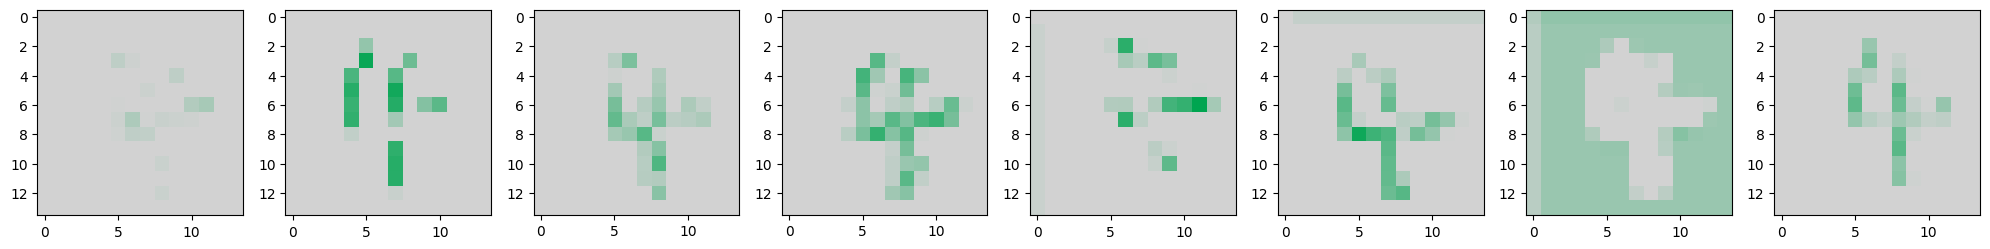

verify
True


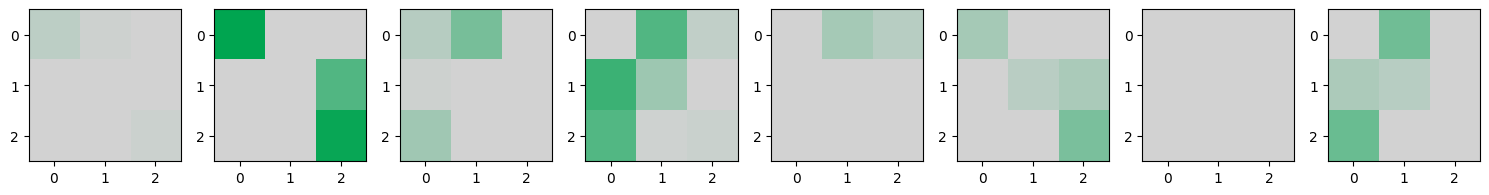

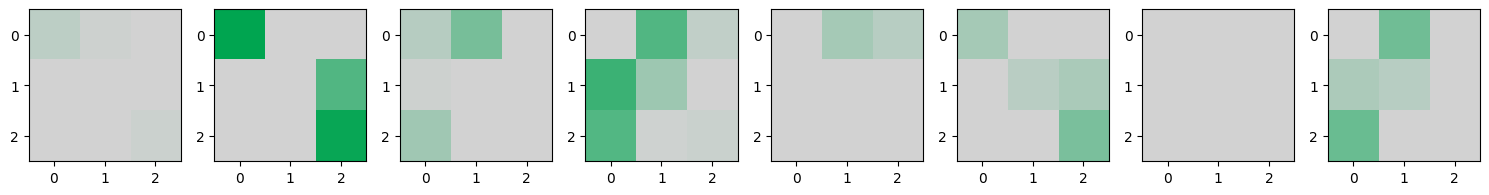

In [18]:
acts = Activation.objects.filter(coordinate__startswith=INPUT_LAYER_NAME, input__alias=sm_ids[0]["input"]).order_by("coordinate")
acts = np.stack([a.data for a in acts])
patch = acts[:, y0:y1, x0:x1]
S(tsl(acts), 20, 8, mode=MODE)
plt.show()


print("verify")
print(np.all(patch == patches[0]))
S(tsl(patch), 15, 8, mode=MODE)
plt.show()
S(tsl(patches[0]), 15, 8, mode=MODE)
plt.show()

Basic components of verifying dictionary learning is working ish

- Sparsity ratio
- Reconstruction loss
- Stability across seeds

For this case, I anyways need to do multiple runs and find the one with the smallest loss.  
For now, lets run the first case only, forget about stability, i need the sparsity plot to see if what im thinking is fine.  

In [ ]:
from typing import Literal


def _single_dict_learn(X, n_components, alg: Literal["minibatch", "basic"], seed=None, **kwargs):
    clz = DictionaryLearning if alg == "basic" else MiniBatchDictionaryLearning
    dl = clz(
        n_components=n_components, random_state=seed, **kwargs
    )
    dl.fit(X)
    codes = dl.transform(X)
    error = np.mean((X - codes @ dl.components_) ** 2)
    return dl, codes, error


def do_dict_learn(inputs, n_components, alg: Literal["minibatch", "basic"] = "basic", n_init=5, **kwargs):
    X = Normalizer("max").fit_transform(inputs)
    kwargs = {
        "alpha": 1,
        "max_iter": 5000,
        **kwargs,
    }
    if n_init == 1:
        dl, codes, error = _single_dict_learn(X, n_components, alg, None, **kwargs)
        return (dl, codes, X), [dl]


    best_dl, best_codes, best_error = None, None, np.inf
    all_dls = []
    for seed in range(n_init):
        dl, codes, error = _single_dict_learn(X, n_components, alg, seed, **kwargs)
        all_dls.append(dl)
        if error < best_error:
            best_dl, best_codes, best_error = dl, codes, error
    return (best_dl, best_codes, X), all_dls


In [ ]:
def get_sparse_codes_ratio_with_more_than_1_active_node(sparse_codes, alpha_for_code_below=0.05):
    idxes = []
    for i in range(len(sparse_codes)):
        non_zero_codes = sparse_codes[i][sparse_codes[i] != 0]
        if len(non_zero_codes) == 0:
            continue
        non_zero_codes = np.abs(non_zero_codes)
        max_val_idx = np.argmax(non_zero_codes)
        thresh = non_zero_codes[max_val_idx] * alpha_for_code_below

        gt_thresh = []
        for j in range(len(non_zero_codes)):
            if j == max_val_idx:
                continue
            if non_zero_codes[j] > thresh:
                gt_thresh.append(non_zero_codes[j])
        if len(gt_thresh) > 0:
            idxes.append(i)

    return len(idxes) / sparse_codes.shape[0]


def get_metrics(dl, sparse_codes, X):
    reconstructed = sparse_codes @ dl.components_
    diff = (X - reconstructed)
    err_sq = np.linalg.norm(diff, axis=1)

    _p = np.percentile
    metrics = {
        "l2": {
            "max": np.max(err_sq),
            "mean": np.mean(err_sq),
            "50": _p(err_sq, 50),
            "75": _p(err_sq, 75),
            "90": _p(err_sq, 90),
            "95": _p(err_sq, 95),
        },
        "err": err_sq,
    }
    return metrics

def l2_to_df(l2_dict):
    return pd.DataFrame.from_dict({k: [v] for k,v in l2_dict.items()})

class UselessDimensionException(Exception):
    pass


def get_sparsity_in_rows(sparse_codes):
    # < 0.2 is good, < 0.1 is quite nice
    each_row_sparsity = ((sparse_codes != 0).sum(axis=1) / sparse_codes.shape[1])
    _p = np.percentile
    return {
        "max": np.max(each_row_sparsity),
        "mean": np.mean(each_row_sparsity),
        "50": _p(each_row_sparsity, 50),
        "75": _p(each_row_sparsity, 75),
        "90": _p(each_row_sparsity, 90),
        "95": _p(each_row_sparsity, 95),
    }

def _non_zero_ratio(arr):
    return len(arr[arr != 0]) / len(arr)

def _single_dim_metrics(sparse_codes, i):
    col = sparse_codes[:, i]
    # now how much of the input the sparse code accounts for
    # that would be, for each row
    # where the current index is non zero
    # we divide the current index by total sum of that row
    mask = col != 0
    contribs = sparse_codes[mask, i] / sparse_codes[mask].sum(axis=1)
    if len(contribs) == 0:
        raise UselessDimensionException(f"contribs were empty, this dimension was not used at all for {i}")

    _p = np.percentile

    return {
        "non_zero": _non_zero_ratio(col),
        "max": np.max(contribs),
        "mean": np.mean(contribs),
        "50": _p(contribs, 50),
        "75": _p(contribs, 75),
        "90": _p(contribs, 90),
        "95": _p(contribs, 95),
    }
    

def get_sparse_metrics(sparse_codes):
    # first, the percentage of rows it actually accounts for
    # for each index we would have this
    # i get one metric per dimension now actually, ill have to plot a bar chart for every run
    # for every dim lol
    metrics = {
        "non_zero": [],
        "max": [], 
        "mean": [], 
        "50": [], 
        "75": [], 
        "90": [], 
        "95": [], 
    }
    for i in range(sparse_codes.shape[1]):
        m = _single_dim_metrics(sparse_codes, i)
        for (k, v) in m.items():
            if k not in metrics:
                raise Exception(f"key {k} not in metrics")
            metrics[k].append(v)
    return {k: np.array(v) for k, v in metrics.items()}

def plot_error_metrics(l2_dicts):
    df = pd.DataFrame.from_dict(l2_dicts, orient="index")
    metrics = ["max", "mean", "50", "75", "90", "95"]
    fig, axes = plt.subplots(2, 3, figsize=(12, 6))

    for ax, metric in zip(axes.flatten(), metrics):
        ax.plot(df.index, df[metric])
        ax.set_title(metric)
    plt.show()

def get_similarities(dl):
    # again, we would need to show a bar chart lol
    similarity = cosine_similarity(dl.components_)
    np.fill_diagonal(similarity, -np.inf)
    return similarity.max(axis=1)


def plot_non_zero_bars(data, num_cols):
    metric = 'non_zero'
    keys = sorted(data.keys())
    n = len(keys)
    num_rows = (n + num_cols - 1) // num_cols
    fig_width = num_cols * 3.5
    fig_height = num_rows * 3
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(fig_width, fig_height))
    axes = np.array(axes).flatten()  # works for both 1D and 2D
    
    for i, key in enumerate(keys):
        ax = axes[i]
        values = data[key][metric]
        x = np.arange(len(values))
        ax.bar(x, values)
        ax.set_title(f'key={key}')
        ax.set_xticks(x)
        ax.set_xticklabels([f'[{j}]' for j in x])
        ax.set_ylim(0, 1.1)
        ax.set_ylabel(metric)
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle(f'"{metric}" per key', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_abnormal_metrics(data, num_cols):
    exclude = {'non_zero'}
    
    # Collect all abnormal (key, metric, values) tuples
    abnormal = []
    for key in sorted(data.keys()):
        for metric, values in data[key].items():
            if metric in exclude:
                continue
            if not np.all(values == 1.0):
                abnormal.append((key, metric, values))
    
    if not abnormal:
        print("No abnormal metrics found.")
        return
    
    n = len(abnormal)
    num_rows = (n + num_cols - 1) // num_cols
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols * 3.5, num_rows * 3))
    axes = np.array(axes).flatten()
    
    for i, (key, metric, values) in enumerate(abnormal):
        ax = axes[i]
        x = np.arange(len(values))
        ax.bar(x, values)
        ax.set_title(f'key={key}  |  {metric}')
        ax.set_xticks(x)
        ax.set_xticklabels([f'[{j}]' for j in x])
        ax.set_ylabel(metric)
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    plt.suptitle('Abnormal metrics', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()


def plot_similarity_bars(data, ncols=3):
    # this is not helping 
    valid = {k: v for k, v in data.items() if len(v) > 1}
    skipped = {k: v for k, v in data.items() if len(v) == 1}
    
    for k in skipped:
        print(f"Warning: key {k} has only 1 element, skipping.")

    n = len(valid)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharey=True)
    axes = np.array(axes).flatten()

    for ax, (k, arr) in zip(axes, valid.items()):
        ax.bar(range(len(arr)), arr)
        ax.set_title(f"k={k}")
        ax.set_xlabel("Component")

    for ax in axes[n:]:
        ax.set_visible(False)

    axes[0].set_ylabel("Max cosine similarity")
    plt.suptitle("Max pairwise cosine similarity per component")
    plt.tight_layout()
    plt.show()


def get_distance_between_seeds_metric(all_dls):
    # mean: < 0.05 is good
    # max < 0.7 ish is good
    # the range is around this, make ssure the orders dont change a lot
    costs = []
    for i in range(len(all_dls)):
        for j in range(i+1, len(all_dls)):
            dl_0, dl_1 = all_dls[i], all_dls[j]
            cost = cosine_distances(dl_0.components_, dl_1.components_)
            row_ind, col_ind = linear_sum_assignment(cost)
            costs.append(cost[row_ind, col_ind])
    c = np.array(costs)
    _p = np.percentile
    return {
        "max": np.max(c),
        "mean": np.mean(c),
        "50": _p(c, 50),
        "75": _p(c, 75),
        "90": _p(c, 90),
        "95": _p(c, 95),
    }

In [31]:
import pandas as pd

l2_dicts = {}
sparse_dicts = {}
similarities = {}
active_per_sample = {}
sparsity_per_row = {}
distance_between_seeds = {}
comps_gt_1_per_row_ratio = [0] # placeholder for 0
for comp in tqdm(range(1,20)):
    (dl, sparse_codes, X), all_dls = do_dict_learn(lin_pw, comp, alpha=1, max_iter=10000, transform_algorithm="lasso_cd")
    try:
        sparse_stats = get_sparse_metrics(sparse_codes)
    except UselessDimensionException as ex:
        print(f"useless dimension encountered, stopping, found-at-comp={comp} cause={ex}", ex)
        break
    error_metrics = get_metrics(dl, sparse_codes, X)
    sparsity_per_row[comp] = get_sparsity_in_rows(sparse_codes)
    active_per_sample[comp] = (sparse_codes != 0).sum(axis=1)
    distance_between_seeds[comp] = get_distance_between_seeds_metric(all_dls)

    similarities[comp] = get_similarities(dl)
    sparse_dicts[comp] = sparse_stats
    l2_dicts[comp] = error_metrics["l2"]
    comps_gt_1_per_row_ratio.append(get_sparse_codes_ratio_with_more_than_1_active_node(sparse_codes))

print("n_components v/s loss")
plot_error_metrics(l2_dicts)

print("n_components v/s sparsity")
plot_error_metrics(sparsity_per_row)

print("n_components v/s distance-between-seeds")
plot_error_metrics(distance_between_seeds)

plt.plot(comps_gt_1_per_row_ratio)
plt.show()

 11%|█         | 2/19 [00:03<00:26,  1.53s/it]


KeyboardInterrupt: 

In [44]:
(dl, sparse_codes, X), all_dls = do_dict_learn(lin_pw, 30, alpha=1, max_iter=30000, transform_algorithm="lasso_cd")

In [33]:
import itertools
def show_dl_comps(comps):
    c = list(itertools.chain.from_iterable([tsl(c.reshape(8,3,3)) for c in comps]))
    S(c, (20,15), 8, mode=MODE)
    plt.show()

In [45]:
get_sparse_codes_ratio_with_more_than_1_active_node(sparse_codes)

0.11494252873563218

In [47]:
recons = sparse_codes @ dl.components_

In [48]:
sparse_codes[0]

array([0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.4377179, 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ,
       0.       , 0.       , 0.       , 0.       , 0.       , 0.       ])

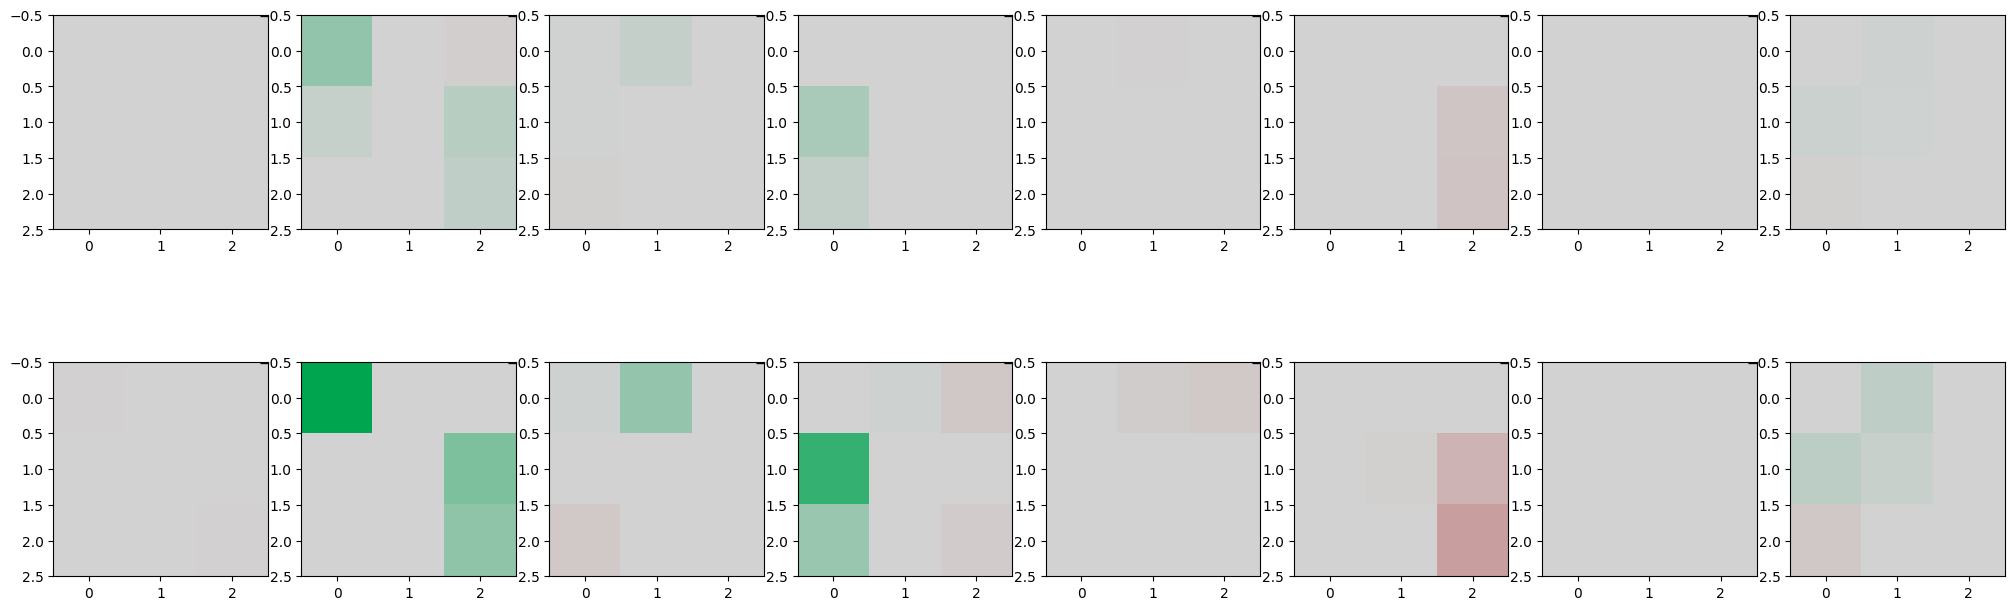

In [49]:
show_72_list([recons[0], X[0]], mode=MODE)

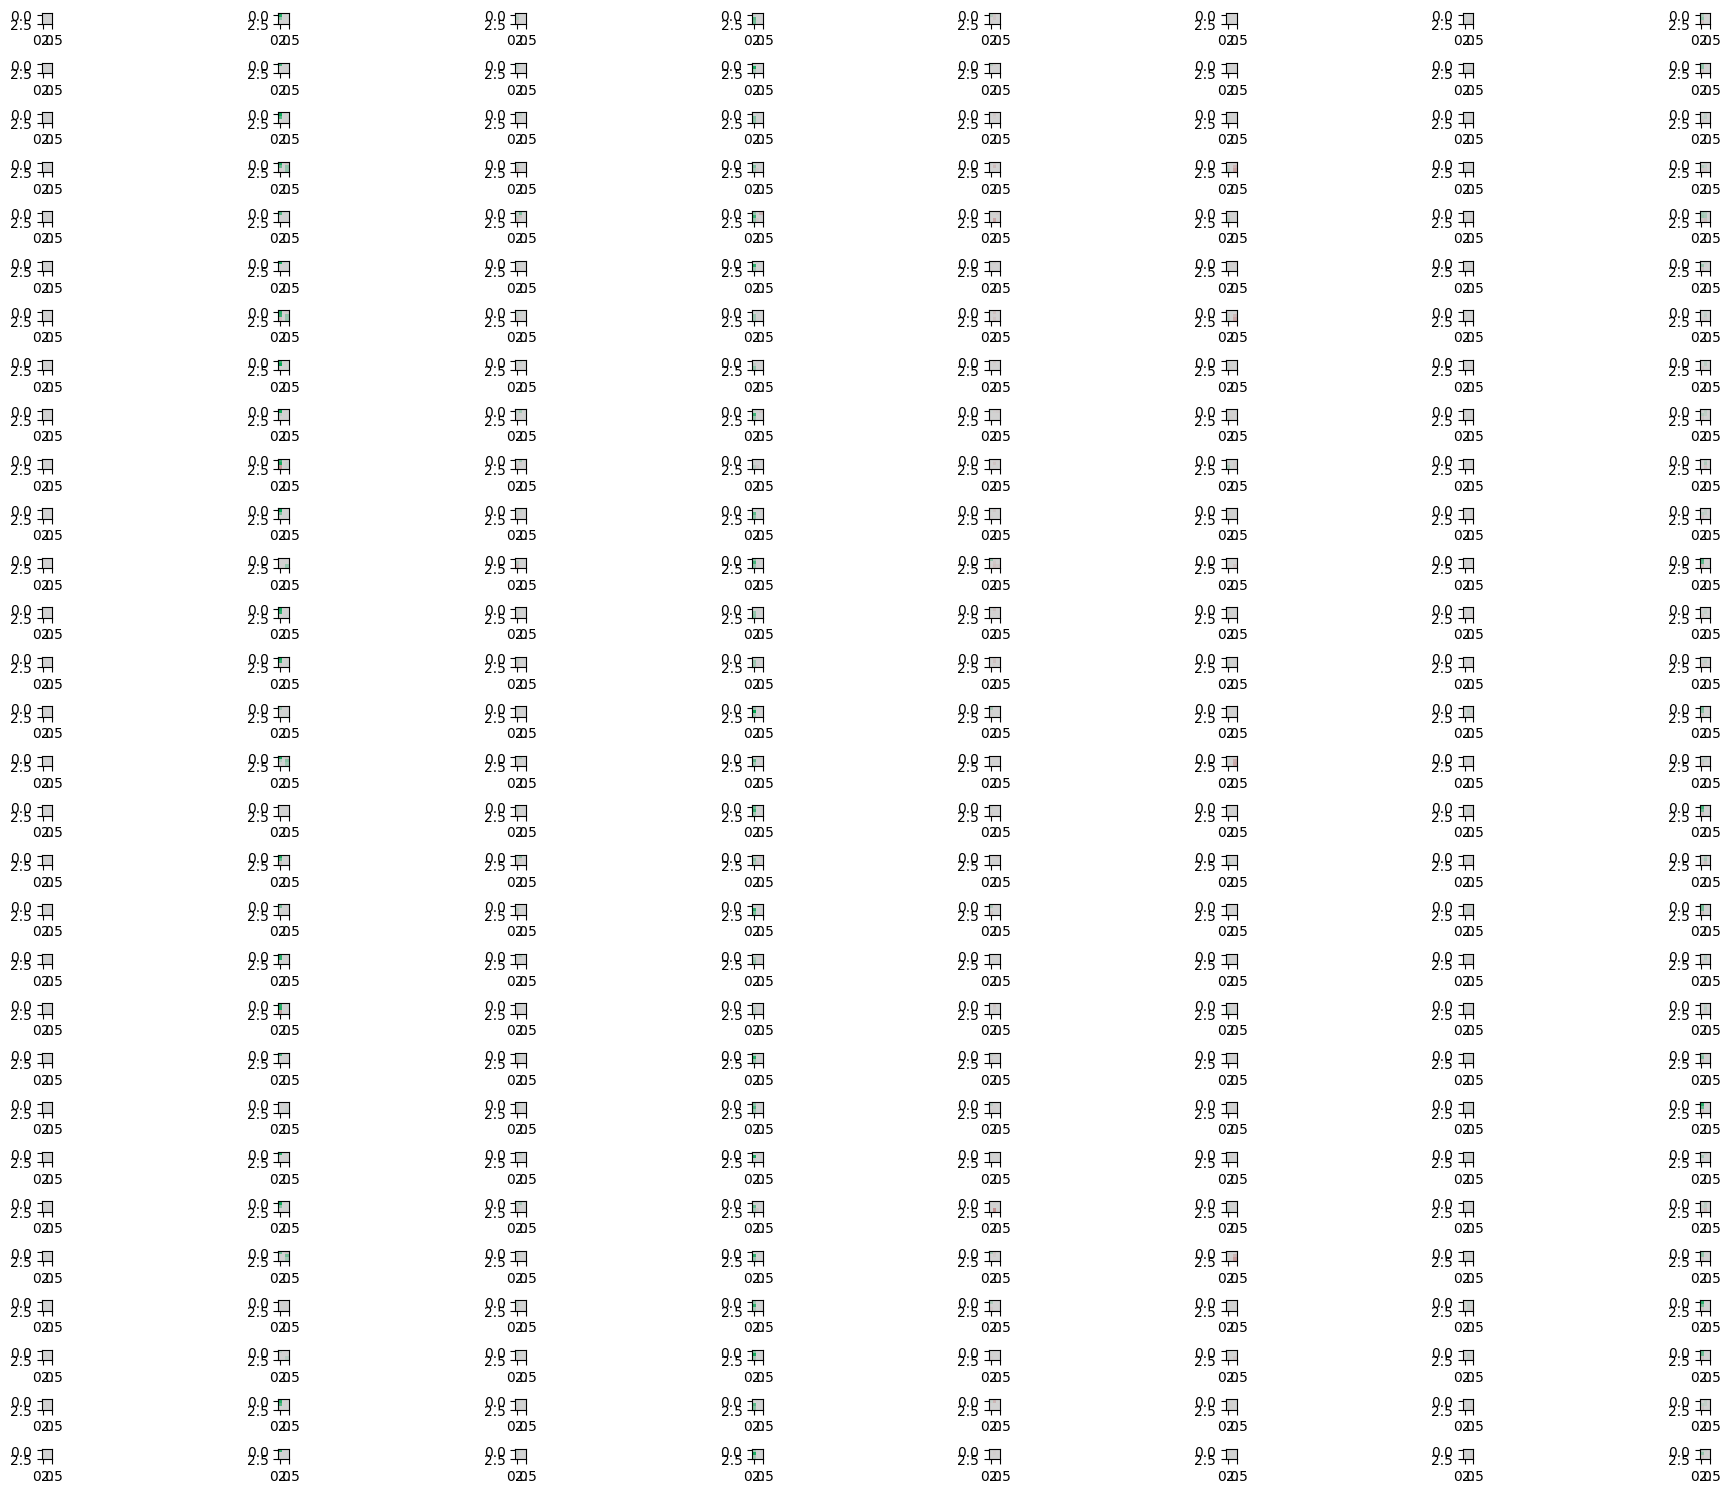

In [50]:
show_dl_comps(dl.components_)

# Train model with sparsity in components

In [240]:
import torch
import numpy as np

def cosine_overlap_penalty(W, H):
    W_norm = W / W.norm(dim=1, keepdim=True).clamp(min=1e-8)
    G = W_norm @ W_norm.T  # (n_atoms, n_atoms)
    mask = ~torch.eye(W.shape[0], dtype=torch.bool, device=W.device)
    return G[mask].abs().mean()


def l1_atom_penalty(W, H):
    """L1 sparsity on atoms themselves."""
    return W.abs().mean()


def contribution_overlap_penalty(W, H):
    """
    Penalize overlap between per-atom contribution vectors within each sample.
    C[i,j] = H[i,j] * W[j]  (scaled atom j for sample i)
    Penalty = mean of squared off-diagonal entries of C @ C.T per sample.
    """
    # C: (n_samples, n_atoms, n_dims)
    C = H.unsqueeze(2) * W.unsqueeze(0)
    # G: (n_samples, n_atoms, n_atoms)
    G = C @ C.transpose(1, 2)
    # mask out diagonal
    n_atoms = W.shape[0]
    mask = ~torch.eye(n_atoms, dtype=torch.bool, device=W.device)
    return G[:, mask].pow(1).abs().mean()
    # return G[:, mask].pow(2).mean()


def sparse_weight_learning(
    X: np.ndarray,
    n_atoms: int,
    lam: float = 0.1,
    n_iter: int = 1000,
    lr: float = 1e-3,
    device: str = "cpu",
    overlap_lam=0.1,
):

    n_samples, n_dims = X.shape
    X_t = torch.tensor(X, dtype=torch.float32, device=device)

    W = torch.nn.Parameter(torch.randn(n_atoms, n_dims, device=device) * 0.1)
    H = torch.nn.Parameter(torch.randn(n_samples, n_atoms, device=device) * 0.1)

    optimizer = torch.optim.Adam([W, H], lr=lr)

    for i in range(n_iter):
        optimizer.zero_grad()

        recon_loss = ((X_t - H @ W) ** 2).mean()
        # lam_current = lam * min(1.0, i / 500)
        penalty = lam * l1_atom_penalty(W, H)
        # overlap_penalty = overlap_lam * contribution_overlap_penalty(W, H)
        # weights = 1.0 / (X_t.abs().mean(dim=1, keepdim=True).clamp(min=1e-8) ** 0.3)
        # weights = weights / weights.mean()  # normalize so overall loss scale doesn't change
        # recon_loss = (weights * (X_t - H @ W) ** 2).mean()
        loss = recon_loss + penalty
        loss.backward()
        optimizer.step()

        # normalize atoms to prevent W shrinking, H exploding
        with torch.no_grad():
            norms = W.norm(dim=1, keepdim=True).clamp(min=1e-8)
            W.data /= norms
            H.data.clamp_(min=0)

        if i % 100 == 0:
            print(f"iter {i:4d} | recon: {recon_loss.item():.4f} | penalty: {penalty.item():.4f}")

    return W.detach().cpu().numpy(), H.detach().cpu().numpy()

In [284]:
def sparse_weight_learning_alternating(
    X: np.ndarray,
    n_atoms: int,
    lam_w: float = 0.1,
    lam_h: float = 0.1,
    n_iter: int = 1000,
    h_steps: int = 10,
    w_steps: int = 5,
    lr: float = 1e-3,
    device: str = "cpu",
):
    n_samples, n_dims = X.shape
    X_t = torch.tensor(X, dtype=torch.float32, device=device)

    W = torch.nn.Parameter(torch.randn(n_atoms, n_dims, device=device) * 0.1)
    H = torch.nn.Parameter(torch.randn(n_samples, n_atoms, device=device) * 0.1)

    opt = torch.optim.Adam([W, H], lr=lr)

    for i in range(n_iter):
        # --- H step: fix W, optimize H for reconstruction + H sparsity ---
        # --- W step: fix H, optimize W for reconstruction + W sparsity ---
        for _ in range(w_steps):
            opt.zero_grad()
            recon_loss = ((X_t - H @ W) ** 2).mean()
            w_penalty = lam_w * W.abs().mean() + lam_h * H.abs().mean()
            loss = recon_loss + w_penalty
            loss.backward()
            opt.step()

        # normalize atoms
        with torch.no_grad():
            norms = W.norm(dim=1, keepdim=True).clamp(min=1e-8)
            W.data /= norms

        if i % 100 == 0:
            recon = ((X_t - H @ W) ** 2).mean().item()
            print(f"iter {i:4d} | recon: {recon:.4f} | w_pen: {lam_w * W.abs().mean().item():.4f} | h_pen: {lam_h * H.abs().mean().item():.4f}")

    return W.detach().cpu().numpy(), H.detach().cpu().numpy()

In [280]:
w, h = sparse_weight_learning_alternating(X, 3, 0.1, 0.005, 2000)

iter    0 | recon: 0.0292 | w_pen: 0.0093 | h_pen: 0.0004
iter  100 | recon: 0.0106 | w_pen: 0.0035 | h_pen: 0.0016
iter  200 | recon: 0.0050 | w_pen: 0.0029 | h_pen: 0.0021
iter  300 | recon: 0.0038 | w_pen: 0.0027 | h_pen: 0.0024
iter  400 | recon: 0.0037 | w_pen: 0.0027 | h_pen: 0.0024
iter  500 | recon: 0.0036 | w_pen: 0.0027 | h_pen: 0.0024
iter  600 | recon: 0.0036 | w_pen: 0.0027 | h_pen: 0.0024
iter  700 | recon: 0.0036 | w_pen: 0.0027 | h_pen: 0.0024
iter  800 | recon: 0.0036 | w_pen: 0.0027 | h_pen: 0.0024
iter  900 | recon: 0.0036 | w_pen: 0.0027 | h_pen: 0.0024
iter 1000 | recon: 0.0036 | w_pen: 0.0027 | h_pen: 0.0024
iter 1100 | recon: 0.0036 | w_pen: 0.0027 | h_pen: 0.0024
iter 1200 | recon: 0.0036 | w_pen: 0.0027 | h_pen: 0.0024
iter 1300 | recon: 0.0036 | w_pen: 0.0027 | h_pen: 0.0024
iter 1400 | recon: 0.0036 | w_pen: 0.0027 | h_pen: 0.0024
iter 1500 | recon: 0.0036 | w_pen: 0.0027 | h_pen: 0.0024
iter 1600 | recon: 0.0036 | w_pen: 0.0027 | h_pen: 0.0024
iter 1700 | re

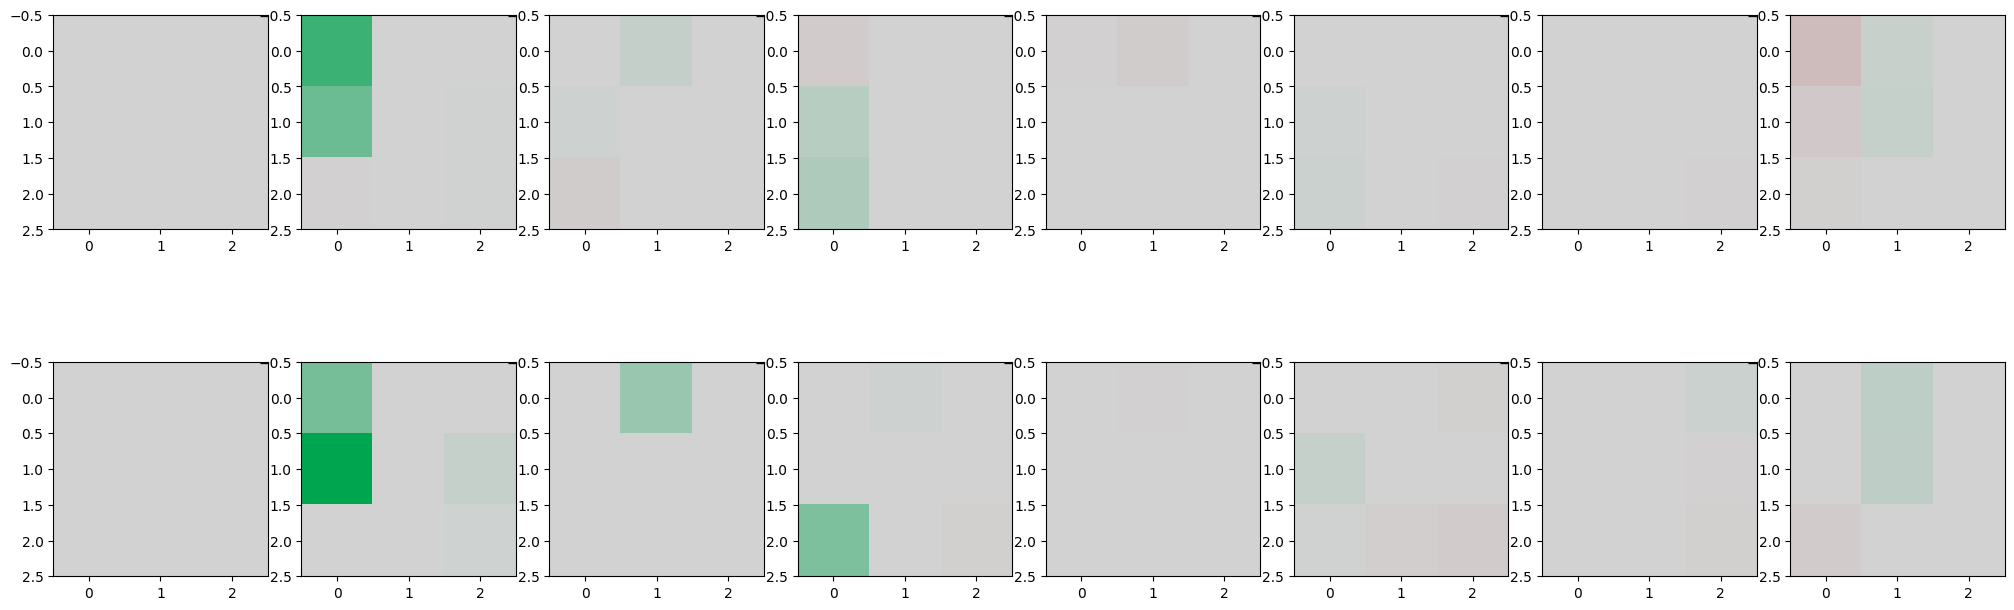

In [281]:
recons = (h @ w)
i = 6
show_72_list([recons[i], X[i]], mode=MODE)

In [282]:
with np.printoptions(3, suppress=True):
    print(h[0])

[-0.944 -0.    -0.433]


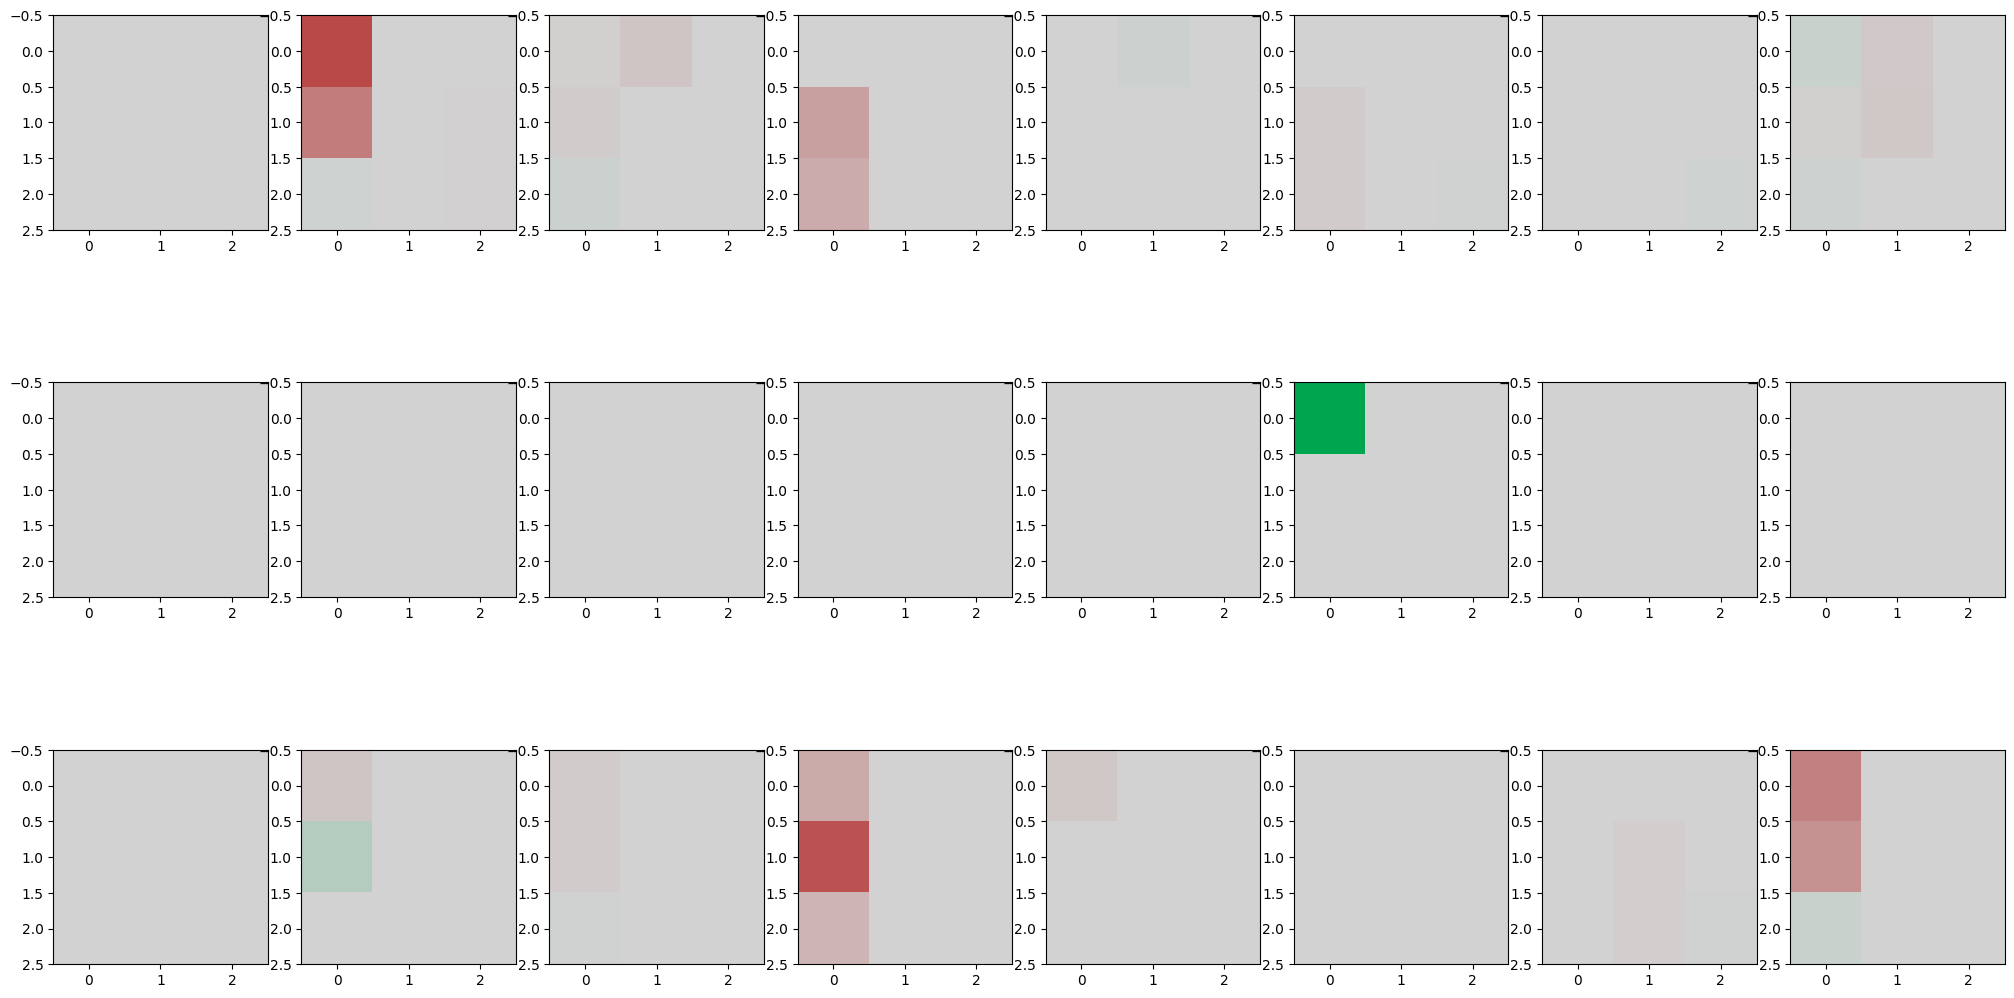

In [283]:
show_72_list(w, mode=MODE)

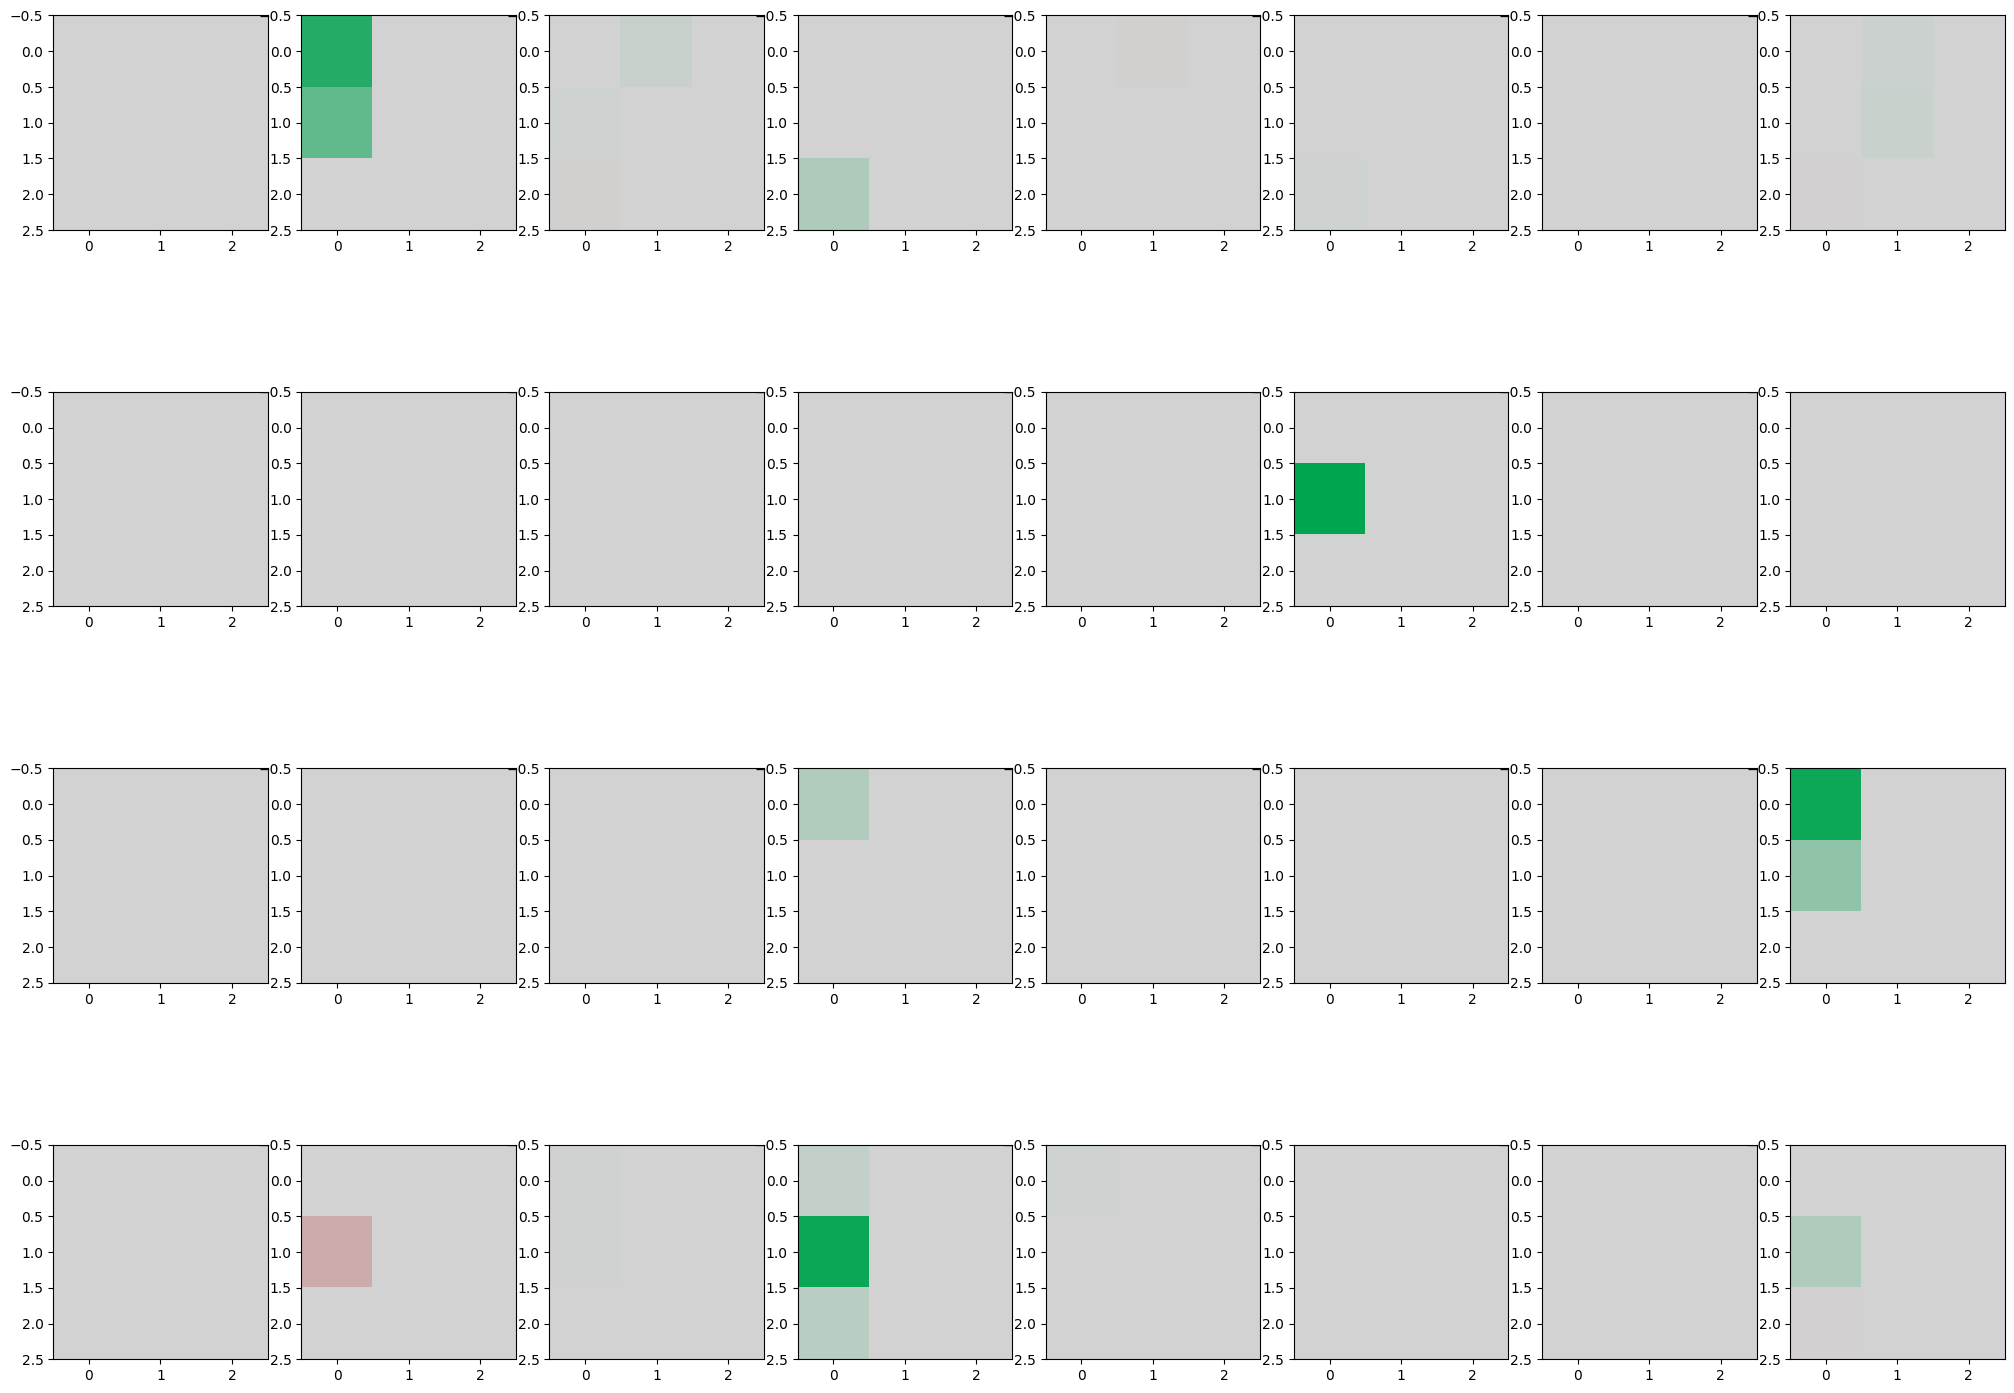

In [247]:
show_72_list(w, mode=MODE)

In [122]:
import numpy as np

# atoms: shape (n_atoms, n_positions)
# each row is one atom, each column is one spatial position

# atoms = np.random.randn(20, 64)  # example: 20 atoms, 64 positions
atoms = dl.components_

# normalize each column (position) across atoms
# so magnitude differences don't dominate
atoms_centered = atoms - atoms.mean(axis=0)
atoms_normalized = atoms_centered / (atoms_centered.std(axis=0) + 1e-8)
# atoms_normalized = atoms

# correlation matrix: shape (n_positions, n_positions)
C = (atoms_normalized.T @ atoms_normalized) / atoms.shape[0]

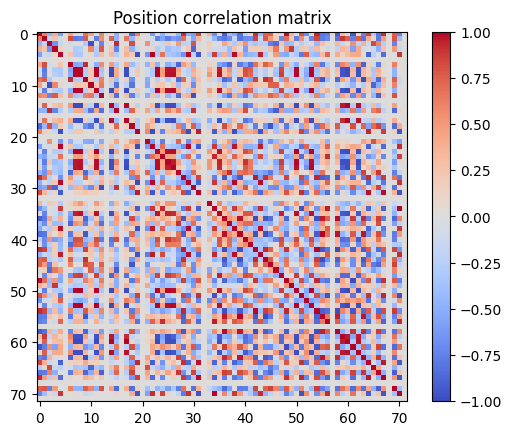

In [283]:
import matplotlib.pyplot as plt

plt.imshow(C, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar()
plt.title('Position correlation matrix')
plt.show()

In [203]:
def make_sparse(patch, num_std=1):
    mean, std = np.mean(patch), np.std(patch)
    thresh = mean + num_std * std

    sparse = patch.copy()
    sparse[np.abs(sparse) < thresh] = 0
    return sparse

# 1 above std dev
sparse_pws = make_sparse(np.stack(lin_pw), 1)

100%|██████████| 59/59 [01:11<00:00,  1.22s/it]


n_components v/s loss


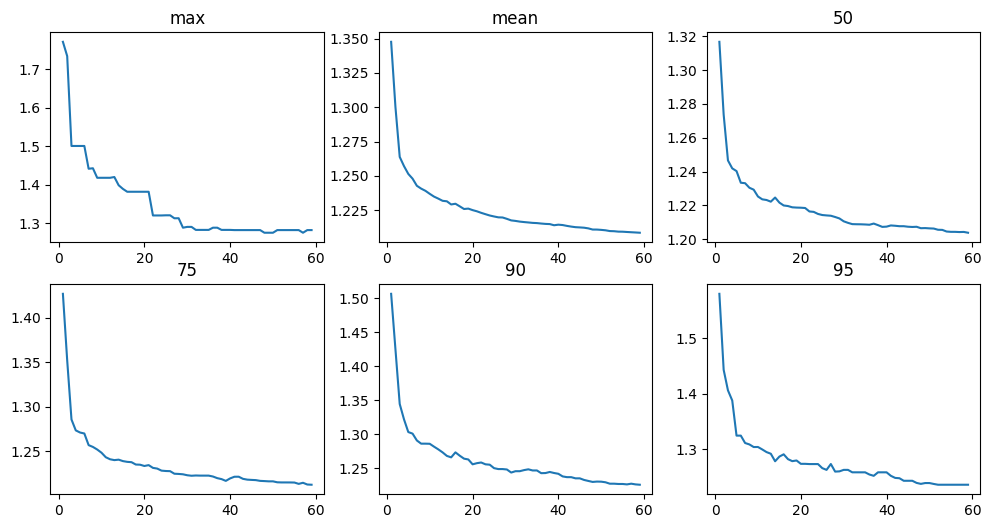

n_components v/s sparsity


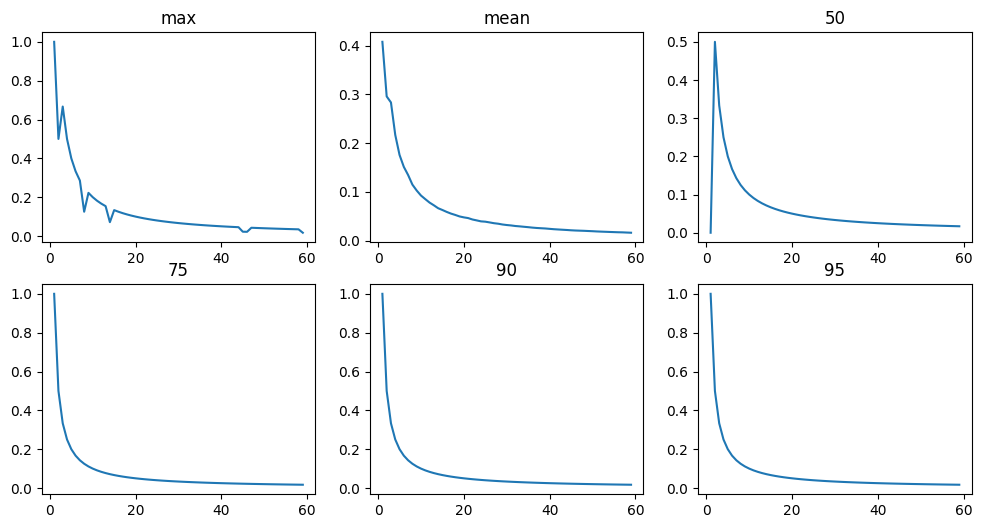

n_components v/s distance-between-seeds


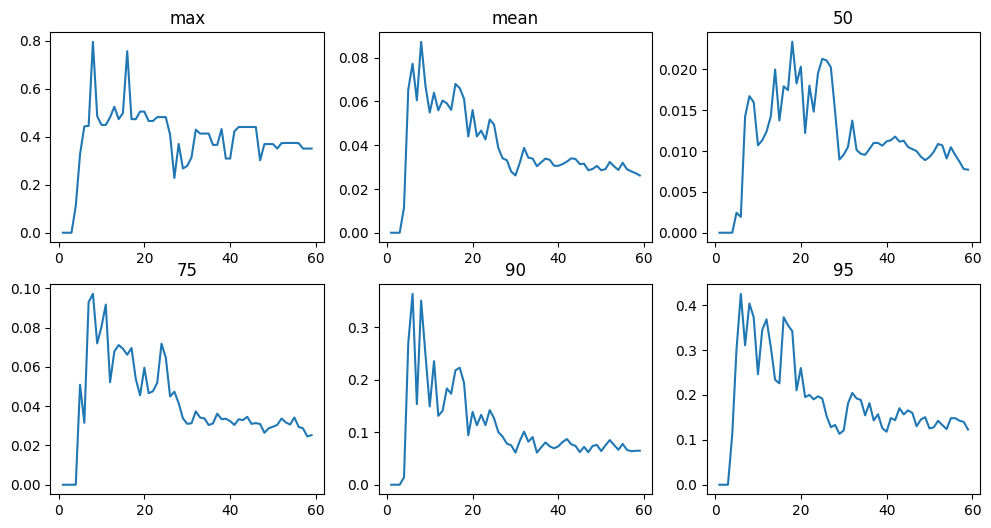

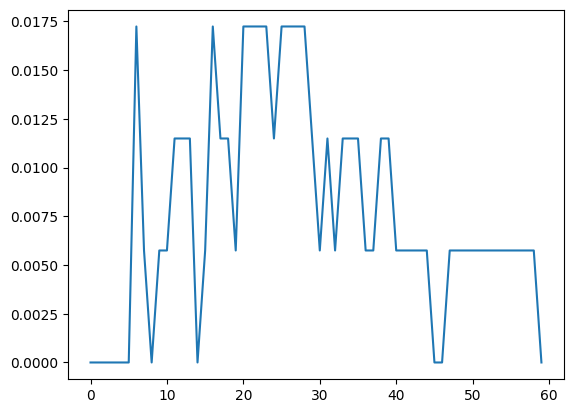

In [214]:
import pandas as pd

# make_sparse(lin_pw)
l2_dicts = {}
sparse_dicts = {}
similarities = {}
active_per_sample = {}
sparsity_per_row = {}
distance_between_seeds = {}
comps_gt_1_per_row_ratio = [0] # placeholder for 0
for comp in tqdm(range(1,60)):
    (dl, sparse_codes, X), all_dls = do_dict_learn(sparse_pws, comp, "basic", alpha=1.2, max_iter=30000, transform_algorithm="lasso_cd")
    # try:
    #     sparse_stats = get_sparse_metrics(sparse_codes)
    # except UselessDimensionException as ex:
    #     print(f"useless dimension encountered, stopping, found-at-comp={comp} cause={ex}", ex)
    #     break
    error_metrics = get_metrics(dl, sparse_codes, X)
    sparsity_per_row[comp] = get_sparsity_in_rows(sparse_codes)
    active_per_sample[comp] = (sparse_codes != 0).sum(axis=1)
    distance_between_seeds[comp] = get_distance_between_seeds_metric(all_dls)

    similarities[comp] = get_similarities(dl)
    sparse_dicts[comp] = sparse_stats
    l2_dicts[comp] = error_metrics["l2"]
    comps_gt_1_per_row_ratio.append(get_sparse_codes_ratio_with_more_than_1_active_node(sparse_codes))

print("n_components v/s loss")
plot_error_metrics(l2_dicts)

print("n_components v/s sparsity")
plot_error_metrics(sparsity_per_row)

print("n_components v/s distance-between-seeds")
plot_error_metrics(distance_between_seeds)

plt.plot(comps_gt_1_per_row_ratio)
plt.show()

### 0 ###


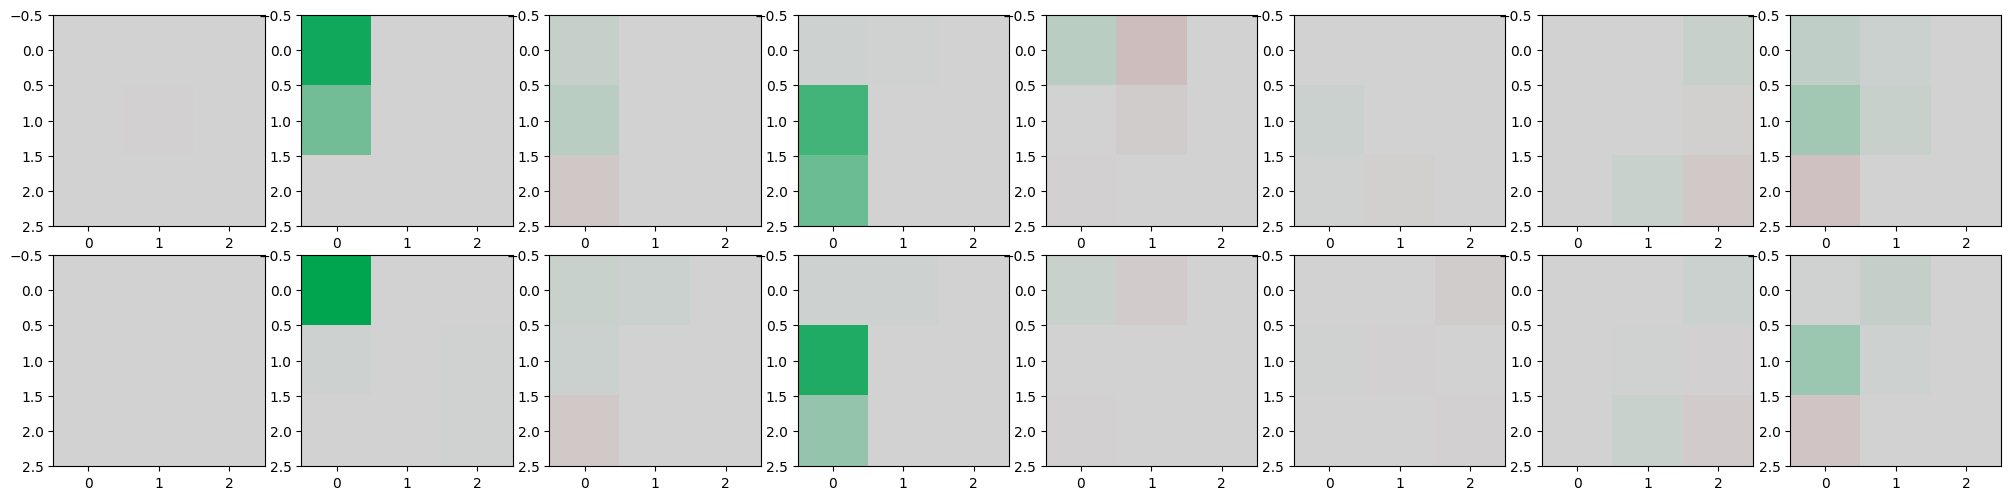

### 1 ###


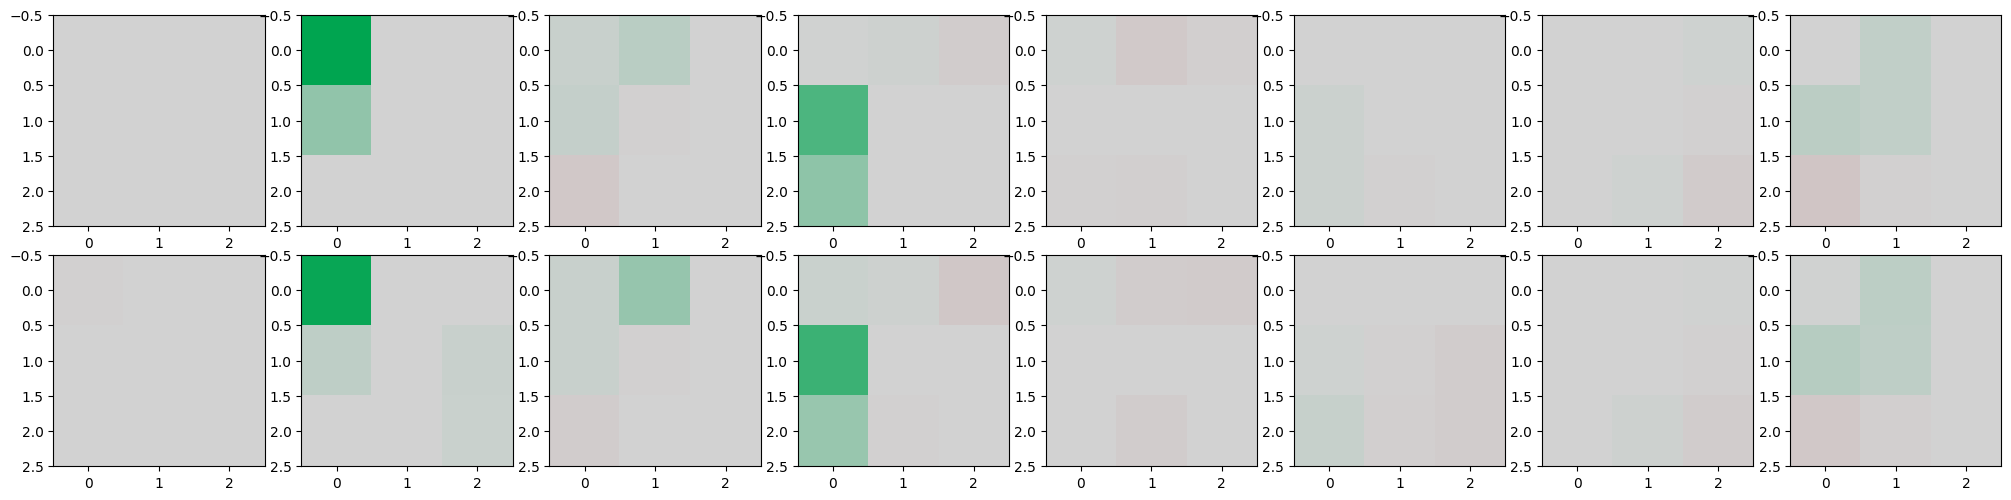

### 2 ###


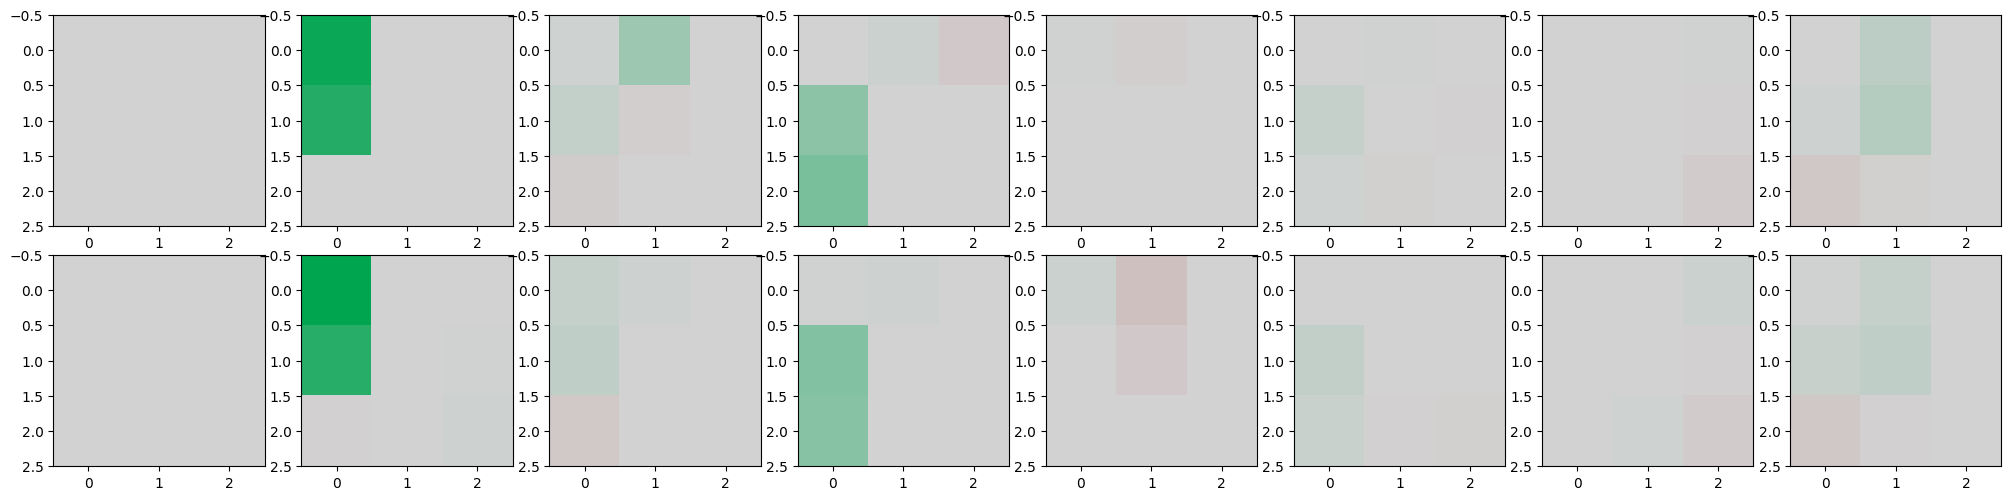

### 3 ###


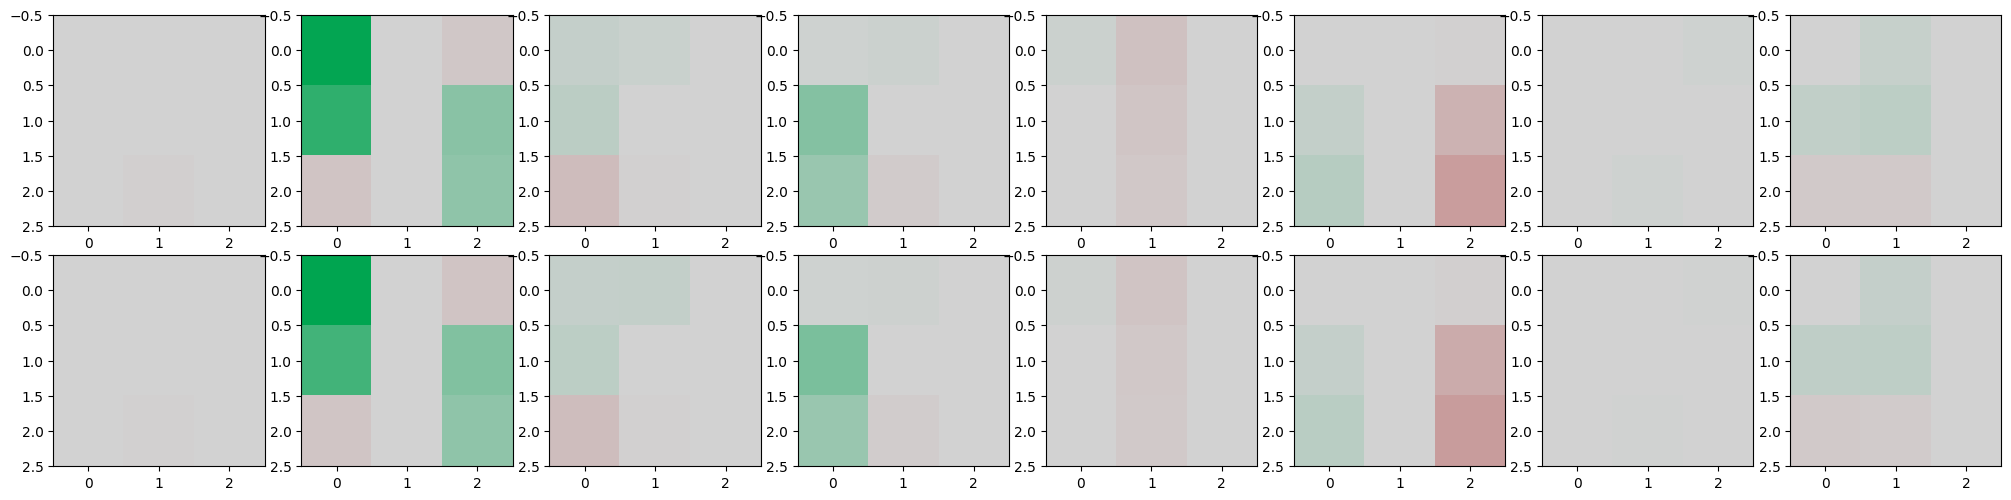

### 4 ###


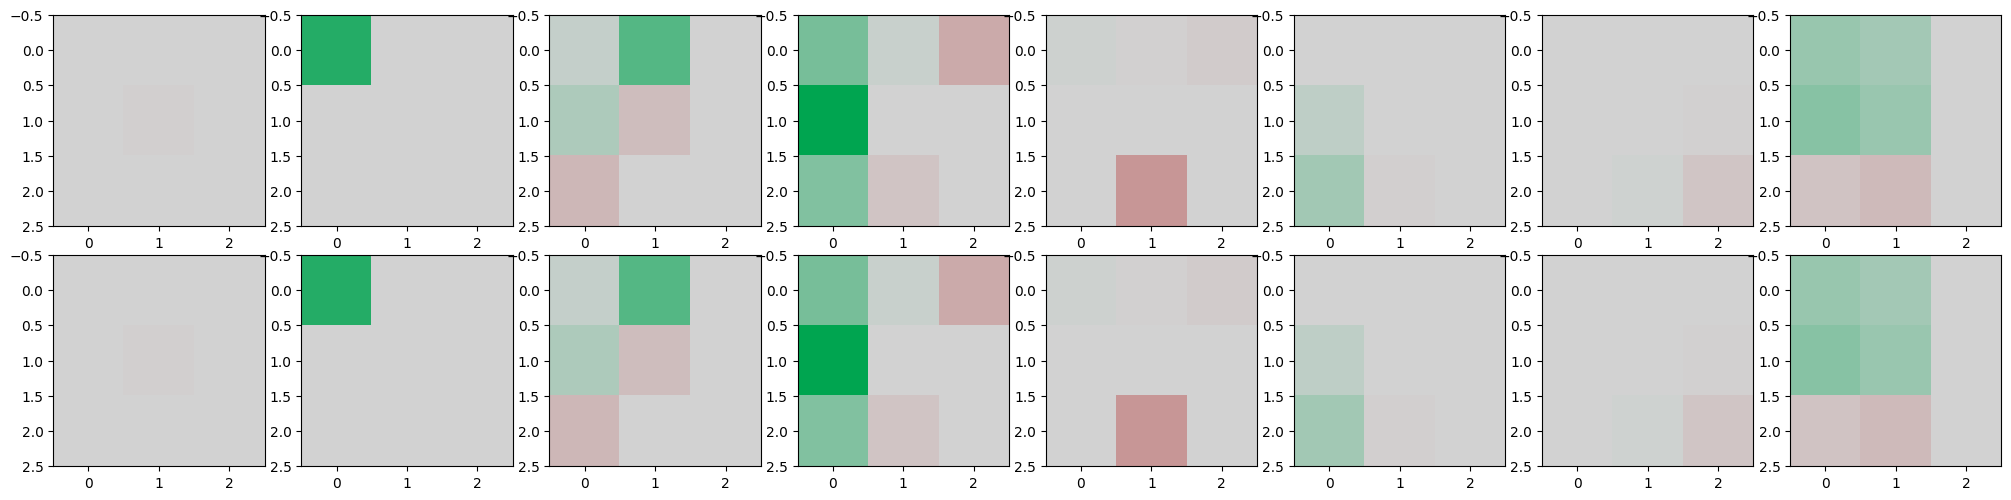

### 5 ###


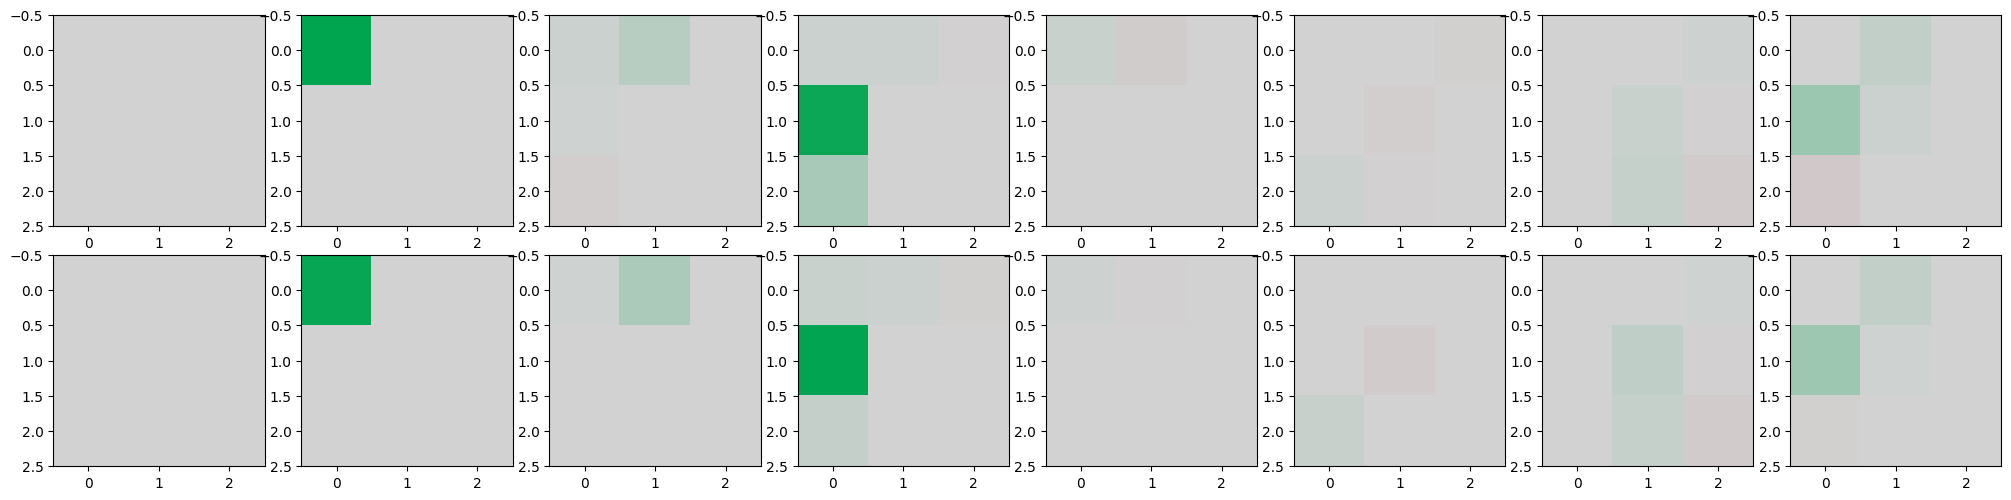

### 6 ###


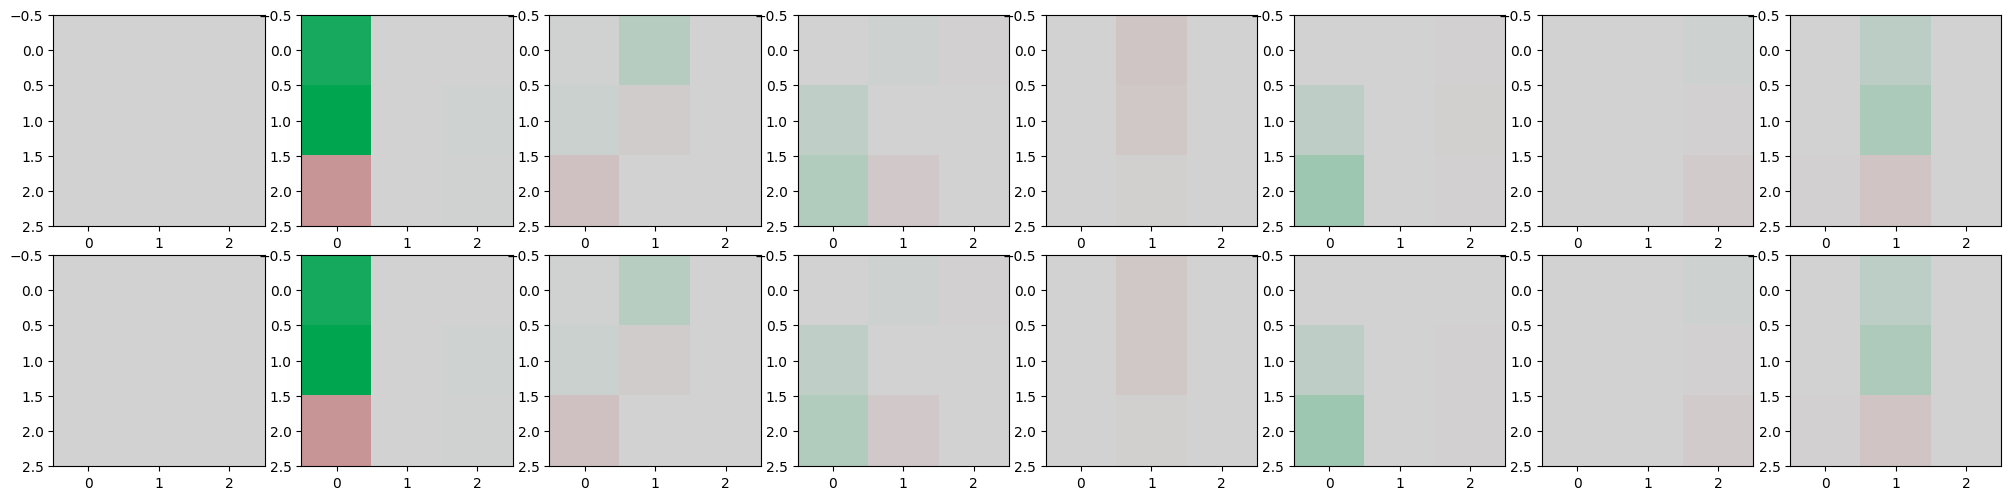

### 7 ###


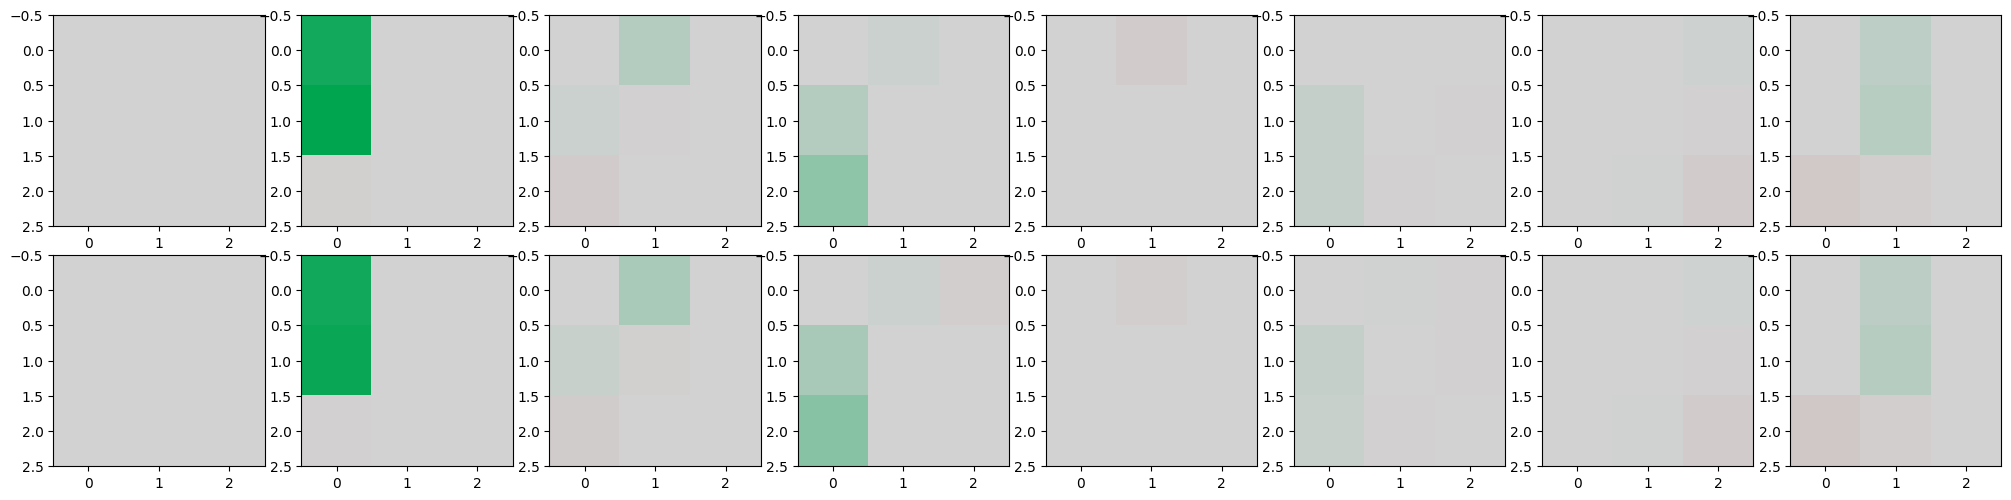

### 8 ###


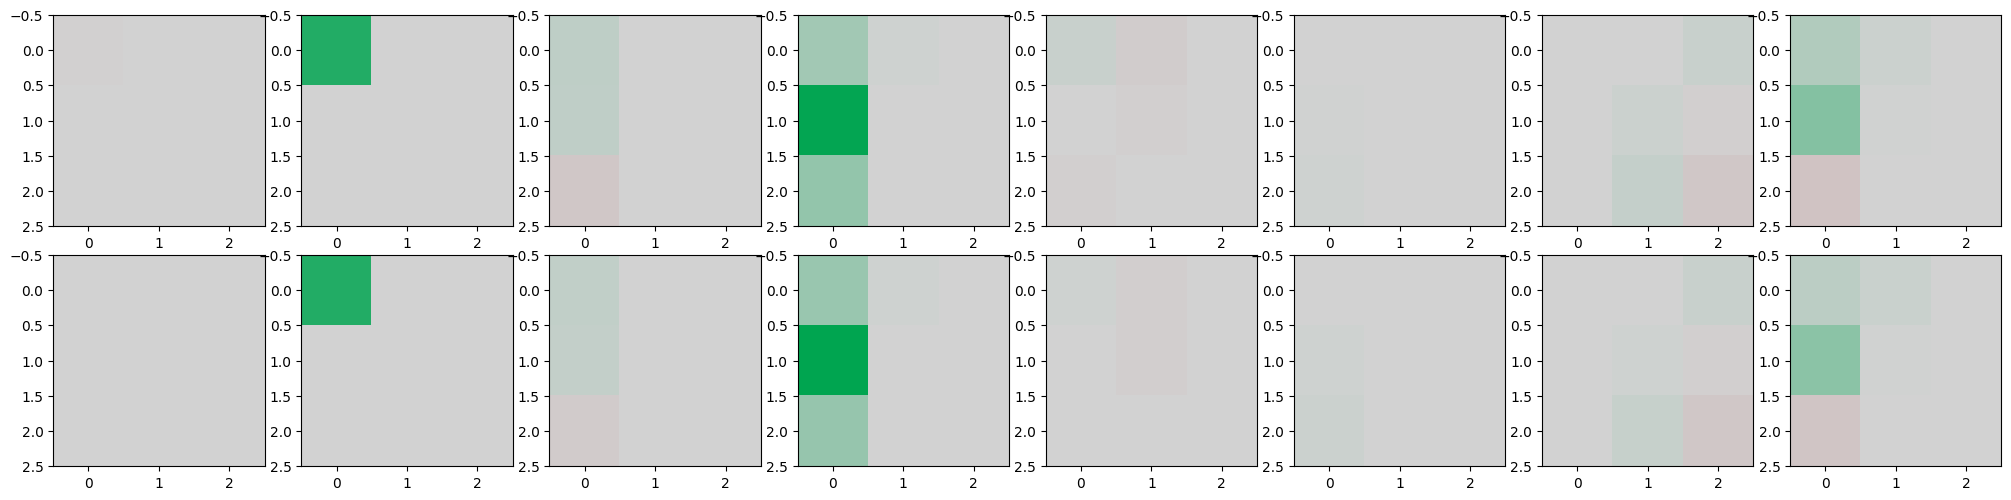

### 9 ###


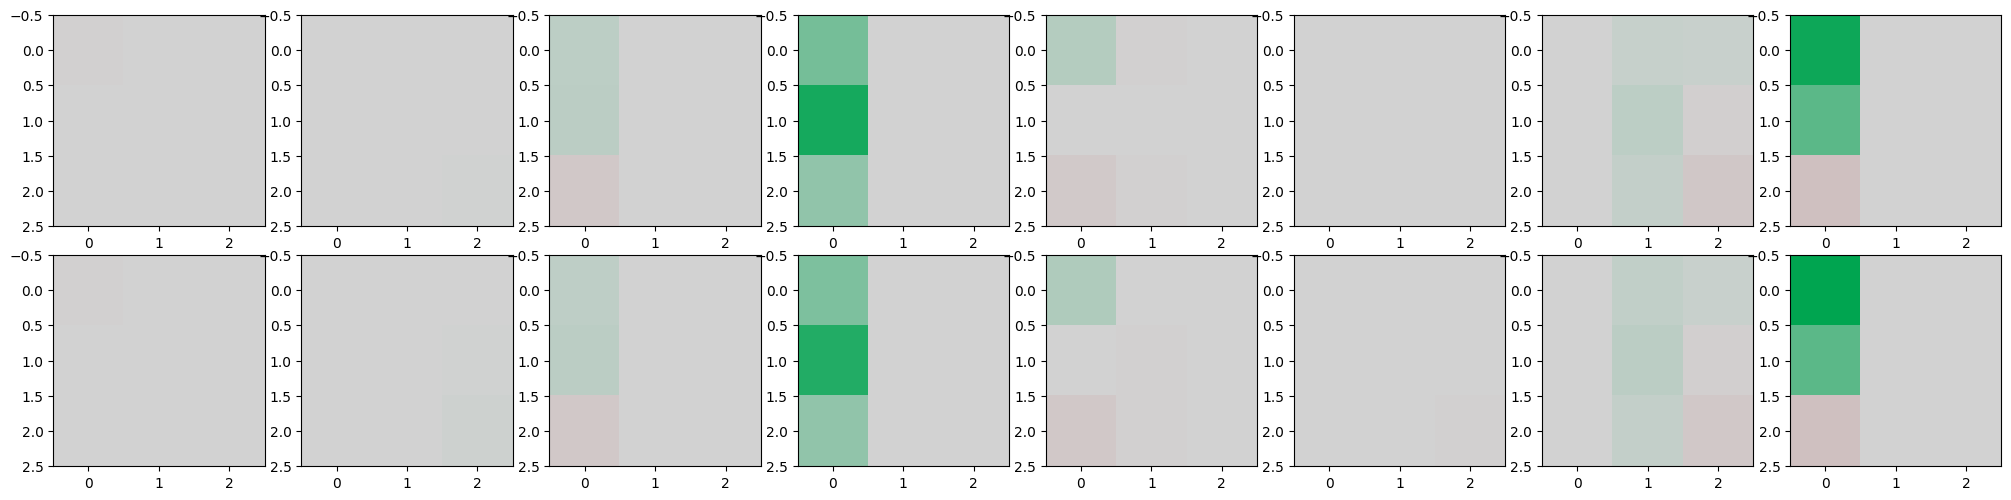

### 10 ###


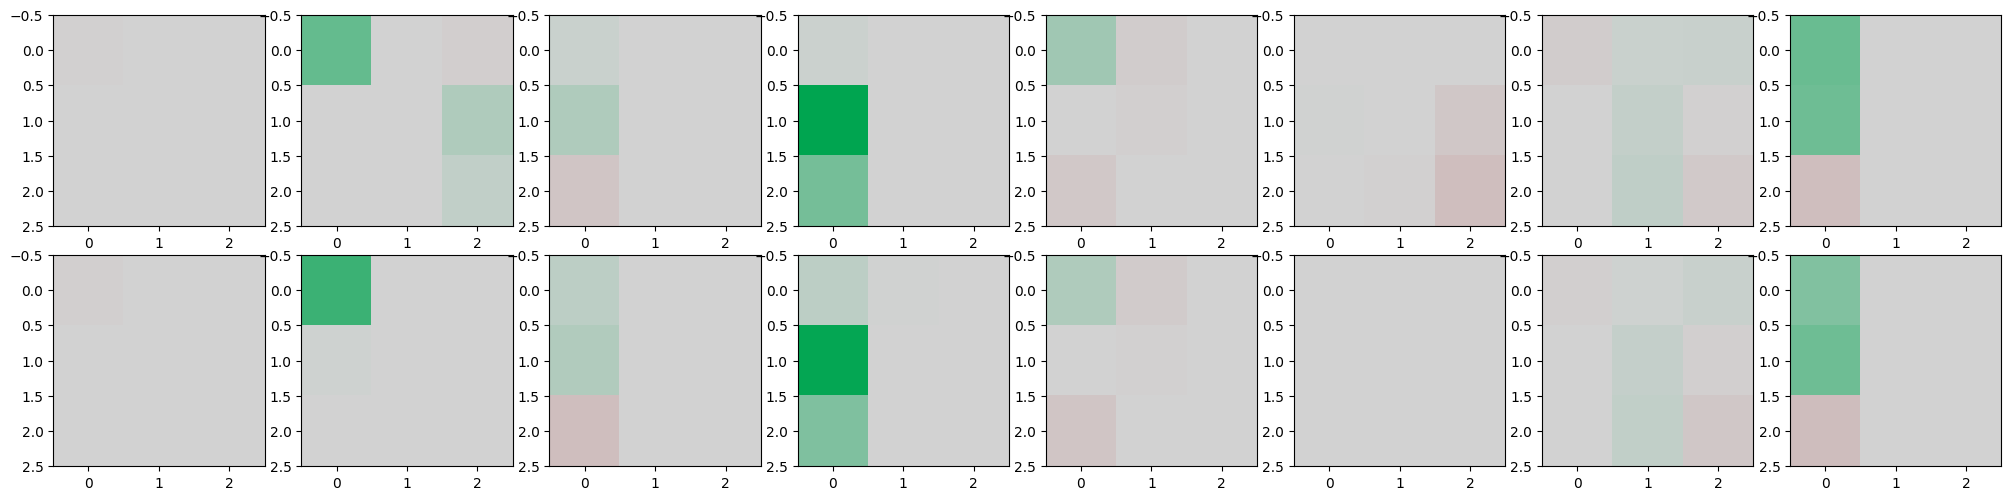

### 11 ###


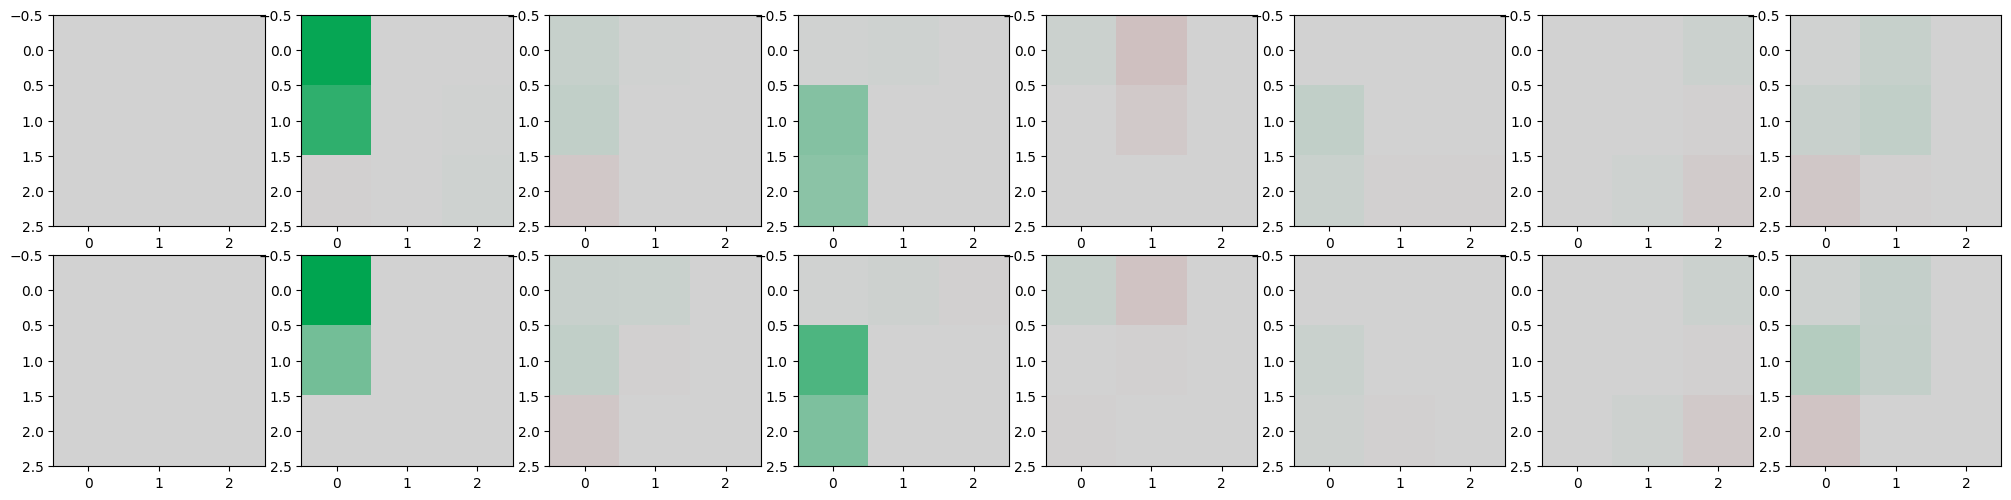

### 12 ###


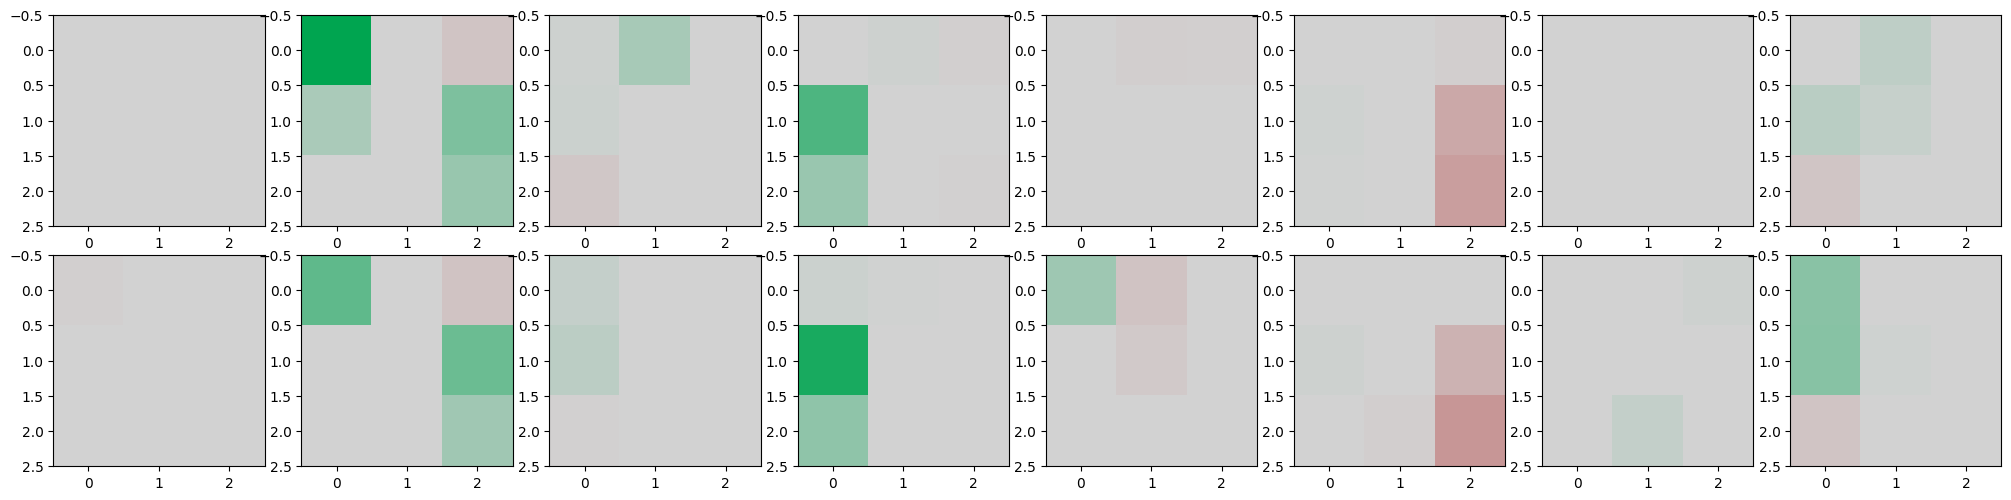

### 13 ###


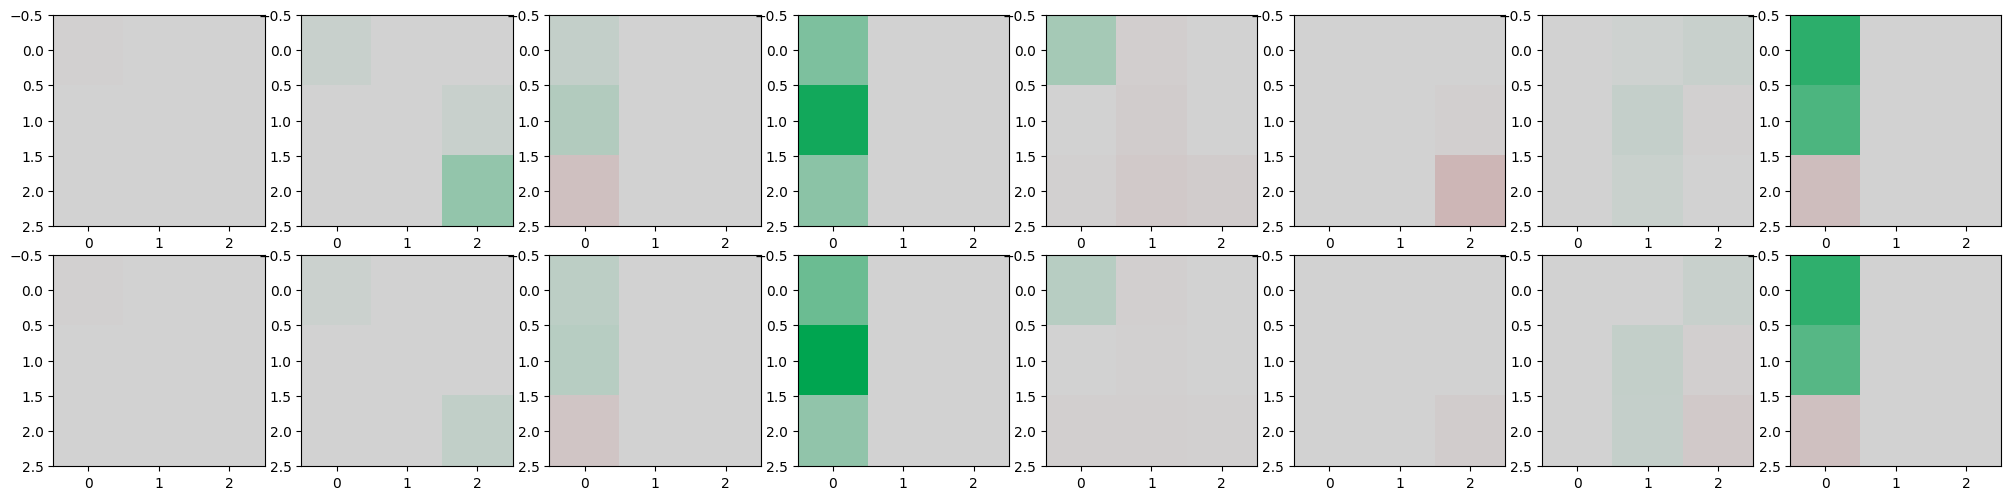

### 14 ###


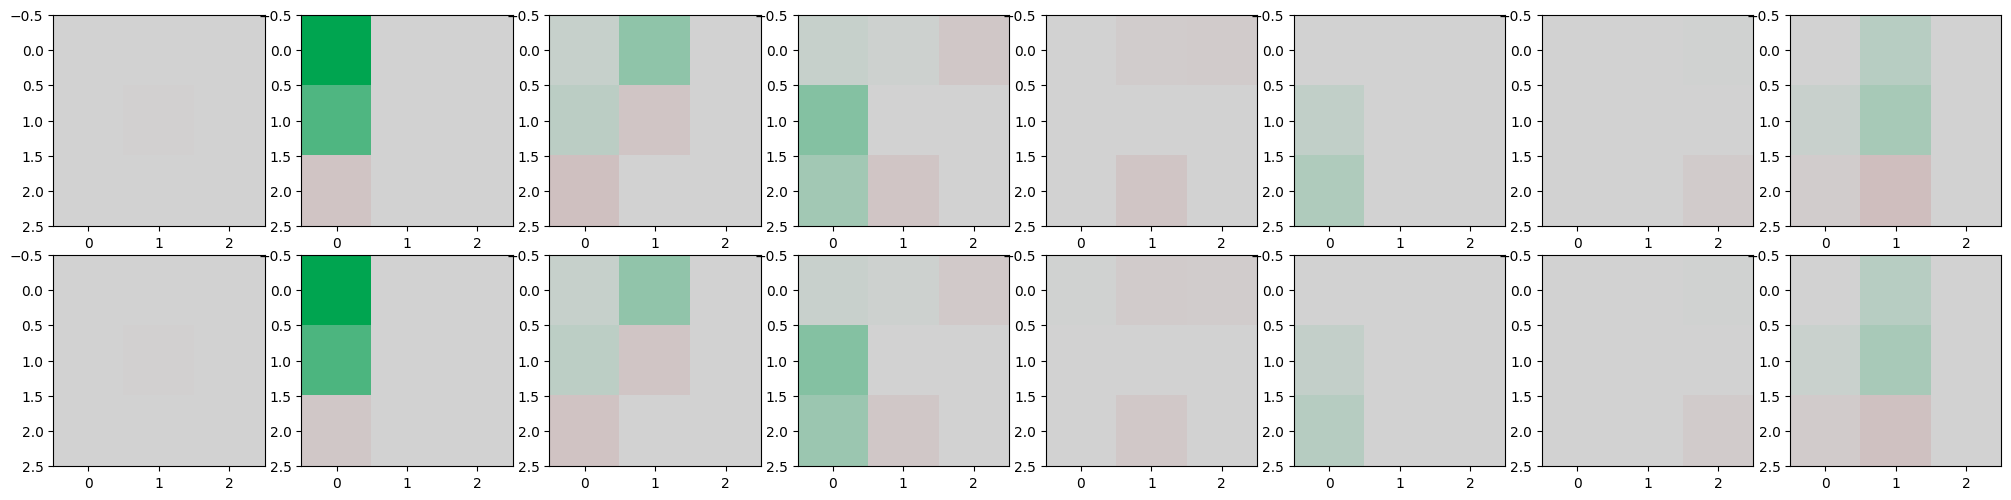

In [ ]:
# quite stable, check if stability score is correct visually

dl_0, dl_1 = all_dls[0], all_dls[1]
cost = cosine_distances(dl_0.components_, dl_1.components_)
row_ind, col_ind = linear_sum_assignment(cost)
for i in range(len(row_ind)):
    print(f"### {i} ###")
    S(
        tsl(dl_0.components_[row_ind[i]].reshape(8,3,3)) + tsl(dl_1.components_[col_ind[i]].reshape(8,3,3)), 
        (20,5), 
        8, 
        mode=MODE
    )
    plt.show()

In [251]:
(dl, sparse_codes, X), all_dls = do_dict_learn(sparse_pws, 15, alpha=1, transform_algorithm="lasso_cd", max_iter=10000)

In [256]:

_sparse_codes = sparse_codes.copy()

# _sparse_codes[0][1] = 1=

code = sparse_codes[0]
code = code.copy()
# code[1] = 0.7

recons_basis = []
for i in range(len(code)):
    row = dl.components_[i]
    val = code[i] * row
    if np.all(val == 0):
        continue
    recons_basis.append(val)

recons = (_sparse_codes @ dl.components_)[0]
real = X[0]

In [261]:
recons[9], real[9] 

(np.float64(0.26232903962027804), np.float64(1.0))

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

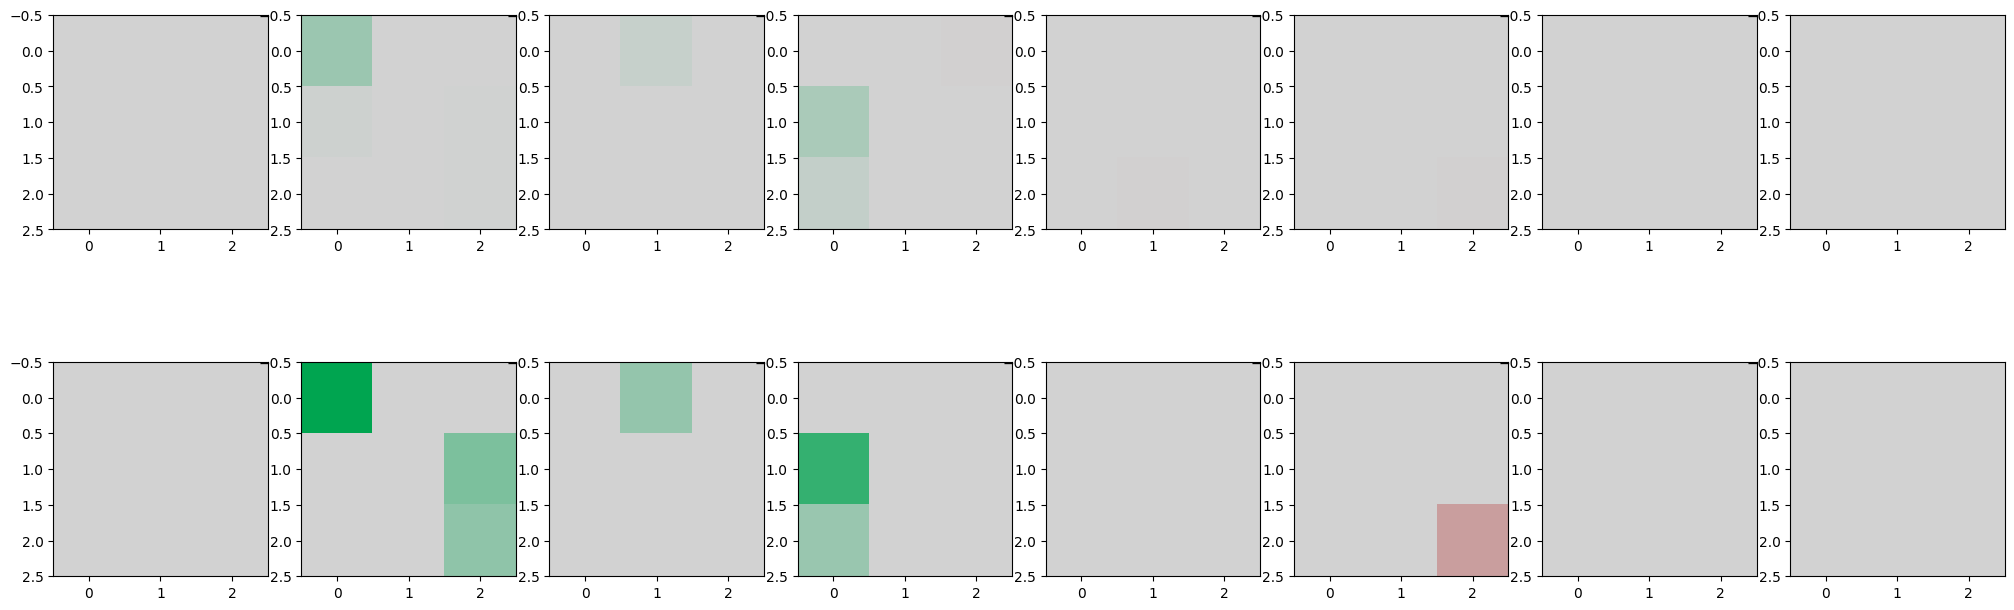

In [257]:
S(tsl(recons.reshape(8,3,3)) + tsl(real.reshape(8,3,3)), (20,8), ncols=8, mode=MODE)

In [217]:
get_sparse_codes_ratio_with_more_than_1_active_node(sparse_codes)

0.034482758620689655

So i feel the position matters more, than the magnitude?  
Although magnitude is also important i guess.  
In the domain of a conv kernel, which recognises edge patterns, position matters more definitely.   

What the pointwise value is at what position is important.  
High importance signal are assumed to be sparse  
Abi im trying to think, ke ek convolution kernel mei, different activations kese identify hote hai.  

My assumption is that a subset of numbers come as a group in the kernel, 
technically mai ese sparsity ekdum badha du, to chalra hai, can i add the error term model now too?  

In my current case, the problem is ke i need to now trim the components, there are too many which would most likely be redundant lol.  lets see in this case of components.   

In [183]:
cds =  cosine_distances(dl.components_)

In [187]:
np.argmin(cds[0][1:])

np.int64(35)

In [188]:
cds[0][36]

np.float64(0.04840148586752058)

In [190]:
dl0.shape

(72,)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

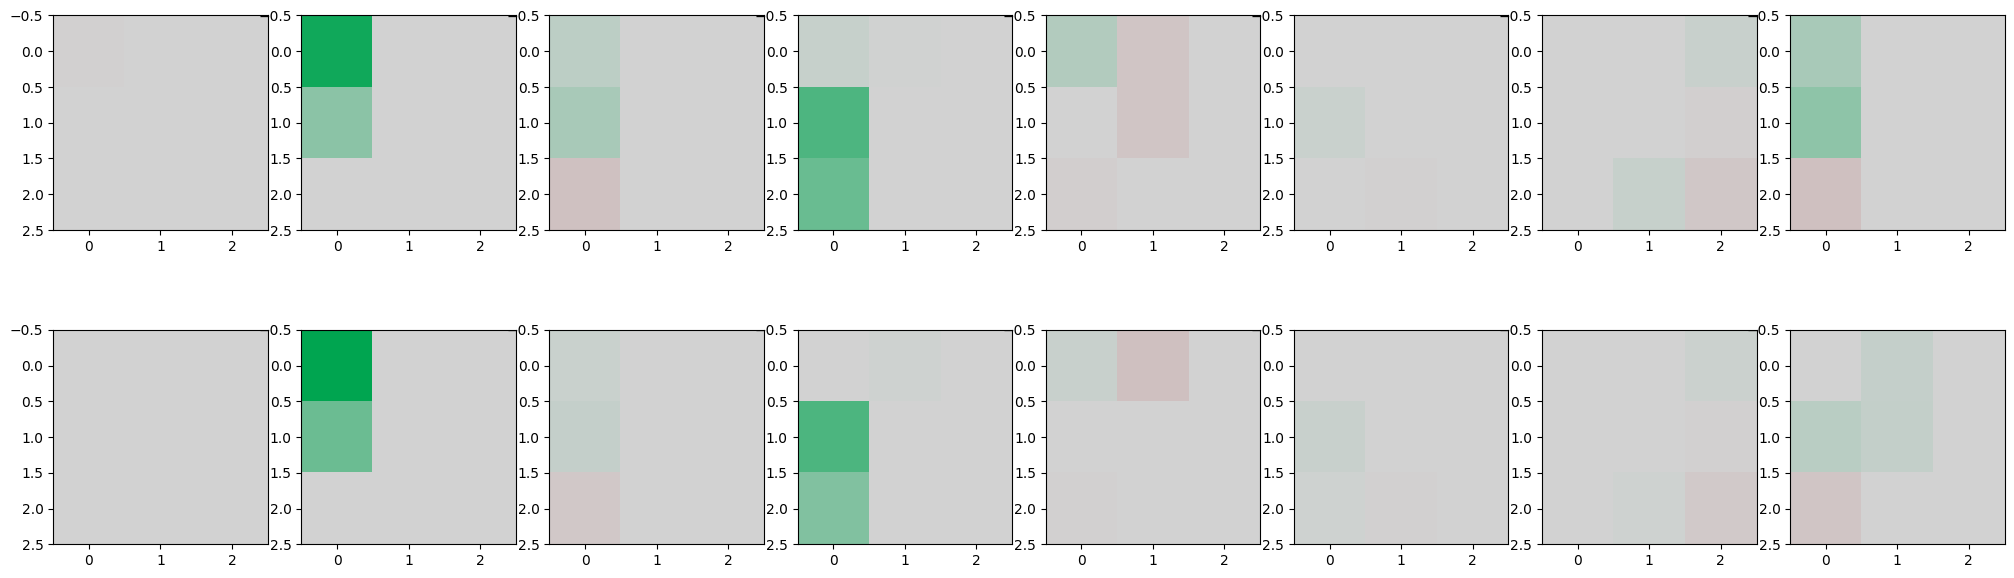

In [191]:
dl0, dl1 = dl.components_[0], dl.components_[36]

# for i in range(len(dl0)):
# print(f"### {i} ###")
S(tsl(dl0.reshape(8,3,3)) + tsl(dl1.reshape(8,3,3)), (20,7), 8, mode=MODE)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >, <Axes: >, <Axes: >, <Axes: >], dtype=object)

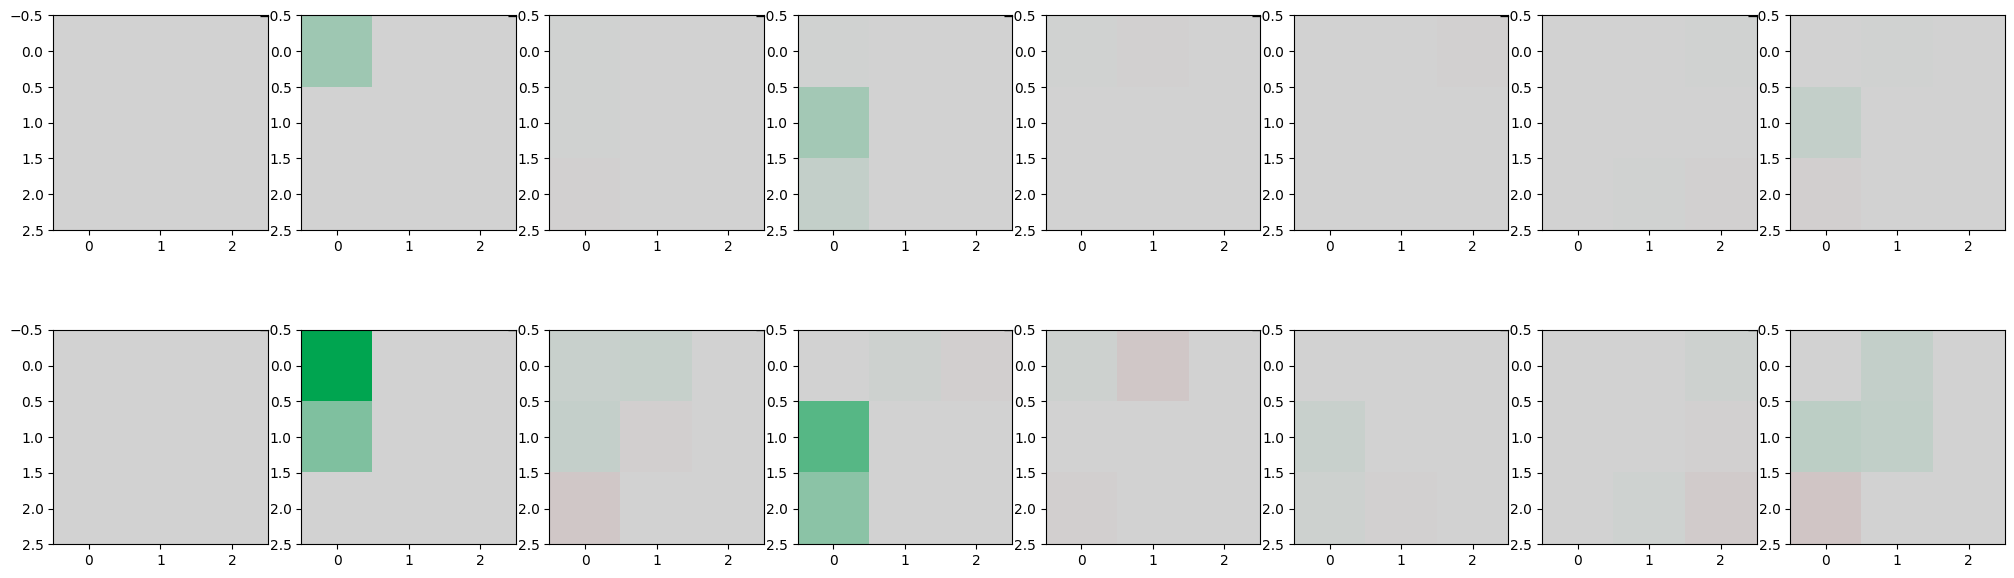

In [177]:
S(tsl(comps[0].reshape(8,3,3)) + tsl(comps[1].reshape(8,3,3)), (20,7), 8, mode=MODE)

I need a more reliable method, which aligns more closely to my goal lol.   

In [135]:
real.shape, len(recons_basis), recons.shape

((72,), 1, (72,))

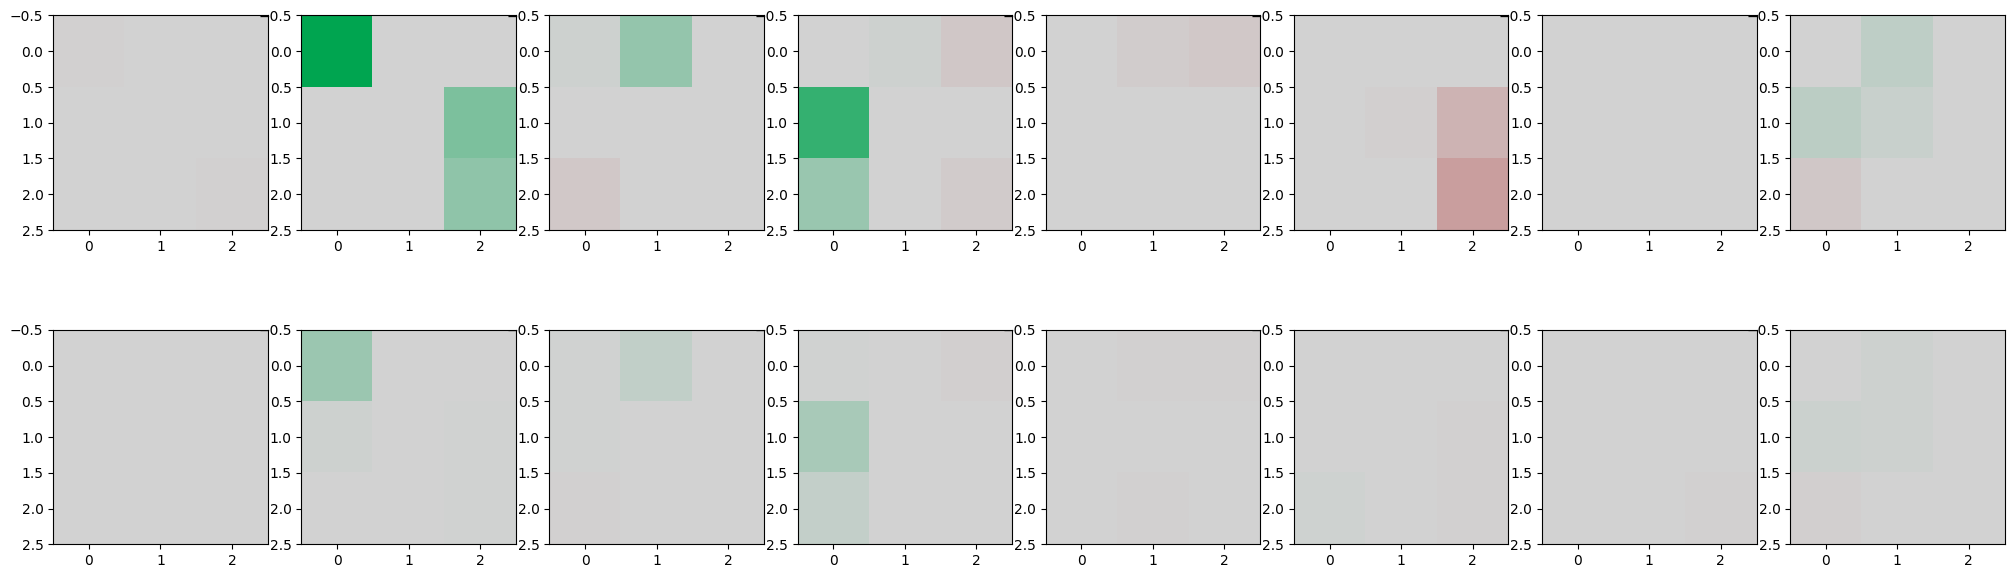

In [136]:
S(tsl(real.reshape(8,3,3)) + tsl(recons.reshape(8,3,3)), (20,7), 8, mode=MODE)
plt.show()

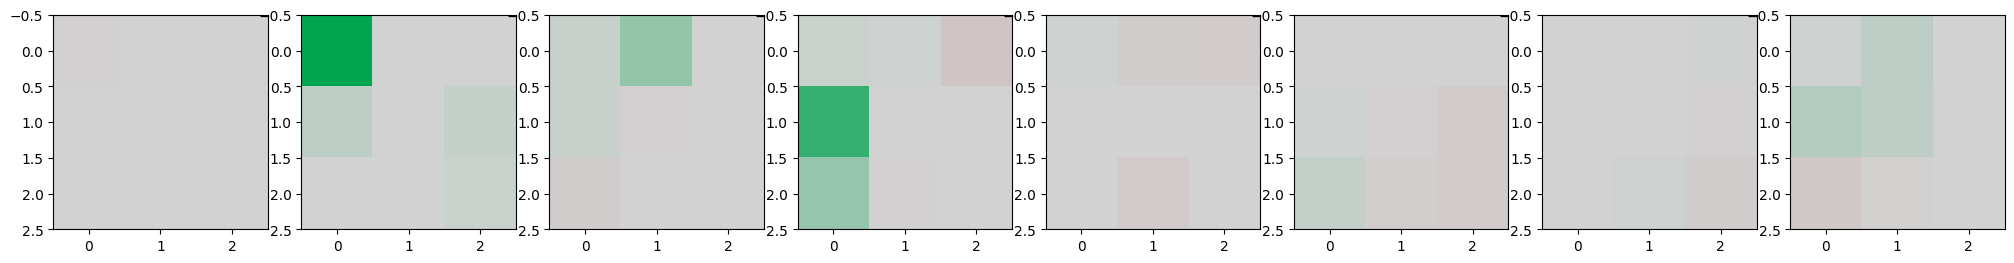

In [137]:
# we are still not getting the correct sparsity.
# it might be useful to look at alternatives now
# hm hmm hmmmmmmmm
# looking frmo simple sparsity pov, the dims are going to explode i think, would be actually reasonable to try 50 dims now
# lasso_cd is working lol
import itertools

flat_basis = list(itertools.chain.from_iterable([tsl(r.reshape(8,3,3)) for r in recons_basis]))
S(flat_basis, (20,20), 8, mode=MODE)
plt.show()

In [ ]:
dl_10, sparse_codes_10, X_10 = do_and_show(lin_pw, 10)

In [ ]:
dl_6, sparse_codes_6, X_6 = do_and_show(lin_pw, 6)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from sklearn.preprocessing import Normalizer
from sklearn.decomposition import DictionaryLearning


# ── Dictionary learning (yours, unchanged) ────────────────────────────────────

# def _do_dict_learn(inputs, n_components, **kwargs):
#     X = Normalizer("max").fit_transform(inputs)
#     kwargs = {
#         "alpha": 1,
#         "max_iter": 1000,
#         **kwargs,
#     }
#     dl = DictionaryLearning(n_components=n_components, **kwargs)
#     dl.fit(X)
#     sparse_codes = dl.transform(X)
#     return dl, sparse_codes, X


# ── Linear error model ─────────────────────────────────────────────────────────

class LinearErrorModel(nn.Module):
    """
    Learns a linear correction W such that:
        x ≈ x_hat + W @ epsilon
    with the constraint that ||W @ epsilon|| << ||x_hat||  (controlled by alpha)
    """
    def __init__(self, d: int):
        super().__init__()
        self.W = nn.Linear(d, d, bias=False)
        nn.init.zeros_(self.W.weight)   # start from no correction

    def forward(self, epsilon: torch.Tensor) -> torch.Tensor:
        return self.W(epsilon)

class NonLinearErrorModel(nn.Module):
    def __init__(self, d: int, hidden_dim: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, d),
        )
        # initialise last layer near zero so we start from no correction
        nn.init.zeros_(self.net[-1].weight)
        nn.init.zeros_(self.net[-1].bias)

    def forward(self, epsilon: torch.Tensor) -> torch.Tensor:
        return self.net(epsilon)

def error_model_loss(
    correction: torch.Tensor,   # W @ epsilon,  shape (N, d)
    epsilon: torch.Tensor,      # residual,     shape (N, d)
    x_hat: torch.Tensor,        # reconstruction, shape (N, d)
    alpha: float,               # scale hyperparameter
    lambda_: float,             # penalty weight
) -> tuple[torch.Tensor, dict]:
    """
    Loss = MSE(correction, epsilon)
         + lambda * mean( relu(||correction|| - alpha * ||x_hat||)^2 )

    Returns (loss, dict of individual terms for logging).
    """
    # how well does the correction explain the residual?
    recon_loss = F.mse_loss(correction, epsilon)

    # scale constraint: correction should be <= alpha * x_hat in norm
    correction_norms = correction.norm(dim=1)           # (N,)
    x_hat_norms      = x_hat.norm(dim=1)                # (N,)
    scale_violation  = F.relu(correction_norms - alpha * x_hat_norms) ** 2
    scale_loss       = scale_violation.mean()

    loss = recon_loss + lambda_ * scale_loss

    return loss, {
        "recon_loss":  recon_loss.item(),
        "scale_loss":  scale_loss.item(),
        "total_loss":  loss.item(),
    }


# ── Training ───────────────────────────────────────────────────────────────────

def train_error_model(
    dl,                         # fitted DictionaryLearning object
    sparse_codes: np.ndarray,   # shape (N, n_components)
    X: np.ndarray,              # normalised input, shape (N, d)
    alpha: float = 0.1,         # correction must be <= alpha * x_hat in norm
    lambda_: float = 1.0,       # scale penalty weight
    lr: float = 1e-3,
    n_epochs: int = 500,
    verbose: bool = True,
    log_every: int = 50,
) -> tuple[LinearErrorModel, list[dict]]:

    # ── build tensors ──────────────────────────────────────────────────────────
    x_hat_np = sparse_codes @ dl.components_          # (N, d)  reconstruction
    epsilon_np = X - x_hat_np                         # (N, d)  residual

    x_hat   = torch.tensor(x_hat_np,   dtype=torch.float32)
    epsilon = torch.tensor(epsilon_np, dtype=torch.float32)

    d = X.shape[1]
    model     = NonLinearErrorModel(d, d // 2)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []

    for epoch in range(1, n_epochs + 1):
        model.train()
        optimizer.zero_grad()

        correction = model(epsilon)
        loss, terms = error_model_loss(correction, epsilon, x_hat, alpha, lambda_)

        loss.backward()
        optimizer.step()

        history.append(terms)
        if verbose and epoch % log_every == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"total={terms['total_loss']:.4f}  "
                f"recon={terms['recon_loss']:.4f}  "
                f"scale={terms['scale_loss']:.4f}"
            )

    return model, history


# ── Evaluation ─────────────────────────────────────────────────────────────────

def get_final_reconstruction_loss(
    model: LinearErrorModel,
    dl,
    sparse_codes: np.ndarray,
    X: np.ndarray,
    alpha,
) -> dict:
    """
    Returns per-sample and aggregate reconstruction metrics:
        loss_base   = ||x_hat - x||^2            (plain dictionary learning)
        loss_final  = ||x_hat + correction - x||^2  (with error model)
        scale_ratio = ||correction|| / ||x_hat||  (how much the correction spent)
    """
    model.eval()
    with torch.no_grad():
        x_hat_np   = sparse_codes @ dl.components_
        epsilon_np = X - x_hat_np

        x       = torch.tensor(X,          dtype=torch.float32)
        x_hat   = torch.tensor(x_hat_np,   dtype=torch.float32)
        epsilon = torch.tensor(epsilon_np, dtype=torch.float32)

        correction = model(epsilon)
        x_final    = x_hat + correction

        loss_base  = ((x_hat  - x) ** 2).mean(dim=1)   # (N,)
        loss_final = ((x_final - x) ** 2).mean(dim=1)  # (N,)

        scale_ratio = correction.norm(dim=1) / (x_hat.norm(dim=1) + 1e-8)

    mean_scale_ratio = scale_ratio.mean().item()
    return {
        # aggregate
        "mean_loss_base":   loss_base.mean().item(),
        "mean_loss_final":  loss_final.mean().item(),
        "mean_scale_ratio": mean_scale_ratio,
        # per-sample tensors (useful for plotting)
        "per_sample_loss_base":   loss_base.numpy(),
        "per_sample_loss_final":  loss_final.numpy(),
        "per_sample_scale_ratio": scale_ratio.numpy(),
        "budget_utilisation": mean_scale_ratio / alpha,
    }


def sweep_n_components(
    inputs: np.ndarray,
    component_range: list[int],
    alpha: float = 0.1,
    lambda_: float = 1.0,
    n_epochs: int = 500,
    verbose: bool = False,
    dict_learn_kwargs=None,
) -> list[dict]:
    """
    Runs the full pipeline for each n_components value.
    Returns a list of dicts with keys: n_components, loss_base, loss_final, scale_ratio
    Use the elbow in loss_final to pick n_components.
    """
    results = []

    for n in component_range:
        print(f"\n── n_components={n} ──")
        dict_learn_kwargs = {} if dict_learn_kwargs is None else dict_learn_kwargs
        dl, sparse_codes, X = do_dict_learn(inputs, n_components=n, **dict_learn_kwargs)
        model, _ = train_error_model(
            dl, sparse_codes, X,
            alpha=alpha, lambda_=lambda_,
            n_epochs=n_epochs, verbose=verbose,
        )
        metrics = get_final_reconstruction_loss(model, dl, sparse_codes, X, alpha)
        results.append({
            "n_components":  n,
            "loss_base":     metrics["mean_loss_base"],
            "loss_final":    metrics["mean_loss_final"],
            "scale_ratio":   metrics["mean_scale_ratio"],
            "budget_utilisation": metrics["budget_utilisation"],
        })
        print(
            f"  base loss={metrics['mean_loss_base']:.4f}  "
            f"final loss={metrics['mean_loss_final']:.4f}  "
            f"scale ratio={metrics['mean_scale_ratio']:.4f}"
            f"budget utilisation={metrics['budget_utilisation']:.4f}"
        )

    return results

In [ ]:
results = sweep_n_components(lin_pw, list(range(1,10)), 0.05, 2)

In [ ]:
# import matplotlib.pyplot as plt

def plot_results(results, alpha):
    ns              = [r["n_components"]      for r in results]
    loss_base       = [r["loss_base"]         for r in results]
    loss_final      = [r["loss_final"]        for r in results]
    budget_util     = [r["scale_ratio"] / alpha for r in results]

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)

    # loss curves
    ax1.plot(ns, loss_base,  "o--", label="base (dict learning only)")
    ax1.plot(ns, loss_final, "o-",  label="final (+ error model)")
    ax1.set_ylabel("mean reconstruction loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # budget utilisation
    ax2.plot(ns, budget_util, "o-", color="tomato", label="budget utilisation")
    ax2.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="target (≤ 1.0)")
    ax2.set_ylabel("scale_ratio / alpha")
    ax2.set_xlabel("n_components")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("elbow.png", dpi=150)
    plt.show()

In [ ]:
plot_results(results, 0.05)

In [ ]:
def sweep_with_seeds(inputs, component_range, seeds, alpha=0.05, lambda_=2.0, n_epochs=500):
    all_results = {}
    
    for seed in seeds:
        print(f"\n── seed={seed} ──")
        results = sweep_n_components(
            inputs, component_range,
            alpha=alpha, lambda_=lambda_,
            n_epochs=n_epochs,
            dict_learn_kwargs={"random_state": seed},  # pass seed to DictionaryLearning
        )
        for r in results:
            n = r["n_components"]
            if n not in all_results:
                all_results[n] = {"loss_base": [], "loss_final": [], "budget_utilisation": []}
            all_results[n]["loss_base"].append(r["loss_base"])
            all_results[n]["loss_final"].append(r["loss_final"])
            all_results[n]["budget_utilisation"].append(r["scale_ratio"] / alpha)
    
    return all_results


def plot_stability(all_results, alpha):
    ns = sorted(all_results.keys())
    
    def mean_std(key):
        means = [np.mean(all_results[n][key]) for n in ns]
        stds  = [np.std(all_results[n][key])  for n in ns]
        return np.array(means), np.array(stds)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 9), sharex=True)

    for key, label, color, ax in [
        ("loss_base",  "base loss",  "steelblue", ax1),
        ("loss_final", "final loss", "seagreen",  ax1),
    ]:
        means, stds = mean_std(key)
        ax.plot(ns, means, "o-", label=label, color=color)
        ax.fill_between(ns, means - stds, means + stds, alpha=0.2, color=color)

    ax1.set_ylabel("mean reconstruction loss")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    means, stds = mean_std("budget_utilisation")
    ax2.plot(ns, means, "o-", color="tomato", label="budget utilisation")
    ax2.fill_between(ns, means - stds, means + stds, alpha=0.2, color="tomato")
    ax2.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="target (≤ 1.0)")
    ax2.set_ylabel("scale_ratio / alpha")
    ax2.set_xlabel("n_components")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig("stability.png", dpi=150)
    plt.show()

In [ ]:
all_results = sweep_with_seeds(lin_pw, range(3,10), [1, 10, 40, 100, 50], alpha=0.05, lambda_=2.0, n_epochs=1000)

In [ ]:
plot_stability(all_results, alpha=0.05)


In [ ]:
len(lin_pw)

In [ ]:
# I have to do the check where we try to detect if kernels are repeating
# in the next iteration
# from sklearn.metrics.pairwise import cosine_distances
# from scipy.optimize import linear_sum_assignment

# Cosine distance matrix: shape (n_components, n_components)

p90 = []
p50 = []
p75 = []

for i in tqdm(range(30,60)):
    dl_0, sparse_codes_0, X_0 = do_dict_learn(lin_pw, n_components=i, random_state=0)
    dl_1, sparse_codes_1, X_1 = do_dict_learn(lin_pw, n_components=i, random_state=1)
    cost = cosine_distances(dl_0.components_, dl_1.components_)
    row_ind, col_ind = linear_sum_assignment(cost)
    c = cost[row_ind, col_ind]
    p90.append(np.percentile(c, 90))
    p75.append(np.percentile(c, 75))
    p50.append(np.percentile(c, 50))

In [ ]:
plt.plot(p90)

In [ ]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# X is your data matrix, shape (1373, 72)
pca = PCA()
pca.fit(lin_pw)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

# Print thresholds
for thresh in [0.80, 0.90, 0.95, 0.99]:
    n = np.argmax(cumulative >= thresh) + 1
    print(f"{thresh:.0%} variance explained by {n} components")

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(np.arange(1, len(explained)+1), explained, 'o-', markersize=3)
ax1.set_xlabel("Component")
ax1.set_ylabel("Explained variance ratio")
ax1.set_title("Scree plot")
ax1.axhline(y=0, color='k', linewidth=0.5)

ax2.plot(np.arange(1, len(cumulative)+1), cumulative, 'o-', markersize=3)
ax2.set_xlabel("Number of components")
ax2.set_ylabel("Cumulative explained variance")
ax2.set_title("Cumulative variance")
for thresh in [0.80, 0.90, 0.95]:
    ax2.axhline(y=thresh, color='gray', linestyle='--', linewidth=0.8, label=f"{thresh:.0%}")
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:

# # Convert matched distances → similarities
# matched_similarities = 1 - cost[row_ind, col_ind]   # cosine similarity
# mean_sim = matched_similarities.mean()
# return row_ind, col_ind, matched_similarities, mean_sim

In [ ]:
row_ind, col_ind

In [ ]:
cost.shape, dl_0.components_.shape

In [ ]:
with np.printoptions(precision=4, suppress=True):
    print(cost[row_ind, col_ind])

In [ ]:
row_ind, col_ind

In [ ]:
dl, sparse_codes, X = do_dict_learn(lin_pw, 6)
model, history = train_error_model(dl, sparse_codes, X, 0.05, 2)
get_final_reconstruction_loss(model, dl, sparse_codes, X, 0.05)

In [ ]:
with torch.no_grad():
    x_hat_np   = sparse_codes @ dl.components_
    epsilon_np = X - x_hat_np

    x       = torch.tensor(X,          dtype=torch.float32)
    x_hat   = torch.tensor(x_hat_np,   dtype=torch.float32)
    epsilon = torch.tensor(epsilon_np, dtype=torch.float32)

    correction = model(epsilon)
    x_final    = x_hat + correction

In [ ]:
show_72(x_final[0])
show_72(x_hat[0])
show_72(correction[0])

# We have the components and dl

Now i need to know if there is some interpretability.  
How can i do that, lets see lol.  

Now I've got a linear combination of components.   
Ab kese karege ye.  

Sabse pehle to, i would have to see how each of the sparse components look for an example.  
kisi example mei, sparse components dekhke pata chalega, ke individual pattern konsa nikla hai.  
in this case, meko bas vo input image ka patch dekhna hai jo activate hua hai.   


Then i would see if i can interpret the result.  multiple examples with similar sparse components would need checkingo

There is a problem here, the reconstruction has multiple patterns overlapping on the same pixel.  
When i look at a pointwise multiplication, i expect ke vo ek hi jagah pe light up hoga.   

My current point is, i will separate groups of activations, within the same cube.  
If multiple groups have the same pixel lighting up, then it is not separated correctly.  

There are some options that i have:
- make the input data sparser (pick only abs > mean + std values and see if we get better sparsity) in the input patch.  



This is not working by directly using it. What if, i first create a very sparse representation using dictionary leanring, this gives us many duplicates, but this is still a small number of elements.  
In this case then, we have a smaller group to study i guess. Might be useful.  


Now the atoms have already described a large part of the data (its a kind of noise reducer).  
Now we want to find atoms which partition these atoms correctly. So this simply decreases the number of data points i need to check.  

The problem with current approach is that the number of atoms learnt in the first dictionary pass are basically all combinations of (num_features a kernel can extract).  

In [ ]:
def make_sparse(patch, num_std=1):
    mean, std = np.mean(patch), np.std(patch)
    thresh = mean + num_std * std

    sparse = patch.copy()
    sparse[np.abs(sparse) < thresh] = 0
    return sparse
sparse_pws = make_sparse(np.stack(lin_pw), 2)

In [286]:
sparse_pws = make_sparse(np.stack(lin_pw), 2)

In [287]:
l2_dicts = {}
sparse_dicts = {}
similarities = {}
for comp in tqdm(range(1,20)):
    dl, sparse_codes, X = do_dict_learn(sparse_pws, comp, alpha=1)
    try:
        sparse_stats = get_sparse_metrics(sparse_codes)
    except UselessDimensionException as ex:
        print(f"useless dimension encountered, stopping, found-at-comp={comp} cause={ex}", ex)
        break
    error_metrics = get_metrics(dl, sparse_codes, X)

    similarities[comp] = get_similarities(dl)
    sparse_dicts[comp] = sparse_stats
    l2_dicts[comp] = error_metrics["l2"]
plot_error_metrics(l2_dicts)
# plot_non_zero_bars(sparse_dicts, 5)
# plot_abnormal_metrics(sparse_dicts, 4)

  0%|          | 0/19 [00:00<?, ?it/s]/Users/hariomnarang/Desktop/personal/hiccup-ide/backend/.venv/lib/python3.13/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
  5%|▌         | 1/19 [00:00<00:04,  3.70it/s]/Users/hariomnarang/Desktop/personal/hiccup-ide/backend/.venv/lib/python3.13/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary. The requested precision might not have been met.
  return func(*args, **kwargs)
 11%|█         | 2/19 [00:00<00:07,  2.27it/s]/Users/hariomnarang/Desktop/personal/hiccup-ide/backend/.venv/lib/python3.13/site-packages/sklearn/utils/_param_validation.py:191: RuntimeWarning: Orthogonal matching pursuit ended prematurely due to linear dependence in the dictionary.

KeyboardInterrupt: 

In [288]:
dl, sparse_codes, X = do_dict_learn(sparse_pws, 6, transform_algorithm="lars")

In [ ]:
decomposed = []
C = 2
for i in range(len(sparse_codes[C])):
    code = sparse_codes[C][i]
    row = dl.components_[i]
    decomposed.append(code * row)

In [ ]:
import itertools

def _to_list(arr):
    return [a for a in arr]


reshaped = [d.reshape(8,3,3) for d in decomposed]
reshaped = [_to_list(d) for d in reshaped]
reshaped = list(itertools.chain.from_iterable(reshaped))

S(reshaped, (40,40), ncols=6)
plt.show()

In [308]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SubspaceModel(nn.Module):
    def __init__(self, input_dim, num_atoms, hidden_dim=256):
        """
        input_dim  : length of each input vector (k)
        num_atoms  : number of basis vectors in D
        hidden_dim : hidden size of encoder MLP
        """
        super().__init__()

        # D: the dictionary matrix, shape (input_dim, num_atoms)
        # each column is one atom
        self.D = nn.Parameter(torch.randn(input_dim, num_atoms) * 0.1)

        # Encoder: x -> c
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, num_atoms),
        )

    def forward(self, x):
        # x: (batch, input_dim)

        # get coefficients
        c = self.encoder(x)                  # (batch, num_atoms)

        # normalise D column-wise before reconstruction
        D_norm = F.normalize(self.D, dim=0)  # (input_dim, num_atoms)

        # reconstruct
        x_hat = c @ D_norm.T                 # (batch, input_dim)

        return x_hat, c, D_norm

    def overlap_loss(self, D_norm):
        """
        Penalise pairs of atoms for sharing active positions.
        For atoms i and j: sum over positions of (d_i[pos] * d_j[pos])^2
        = ||D_norm.T @ D_norm||^2 minus the diagonal (self-overlap)
        """
        G = D_norm.T @ D_norm                # (num_atoms, num_atoms) gram matrix
        # zero out diagonal (each atom with itself)
        mask = 1 - torch.eye(G.shape[0], device=G.device)
        overlap = (G * mask) ** 2
        return overlap.sum()


def compute_loss(x, x_hat, D_norm, model, lambda_overlap=0.01):
    recon = F.mse_loss(x_hat, x)
    overlap = model.overlap_loss(D_norm)
    return recon + lambda_overlap * overlap, recon, overlap


# --- training loop ---

def train(data_loader, input_dim, num_atoms, epochs=100, lr=1e-3, lambda_overlap=0.01):
    """
    data_loader : pytorch DataLoader yielding batches of shape (batch, input_dim)
    """
    model = SubspaceModel(input_dim, num_atoms)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        total_loss = 0.0
        total_recon = 0.0
        total_overlap = 0.0

        for batch in data_loader:
            x = batch if isinstance(batch, torch.Tensor) else batch[0]

            optimiser.zero_grad()
            x_hat, c, D_norm = model(x)
            loss, recon, overlap = compute_loss(x, x_hat, D_norm, model, lambda_overlap)
            loss.backward()
            optimiser.step()

            total_loss    += loss.item()
            total_recon   += recon.item()
            total_overlap += overlap.item()

        n = len(data_loader)
        print(f"Epoch {epoch+1:03d} | "
              f"loss {total_loss/n:.4f} | "
              f"recon {total_recon/n:.4f} | "
              f"overlap {total_overlap/n:.4f}")

    return model


# # --- example usage ---

# if __name__ == "__main__":
#     from torch.utils.data import TensorDataset, DataLoader

#     # dummy data: 1000 vectors of length 64
#     input_dim = 64
#     num_atoms = 16
#     data = torch.randn(1000, input_dim)

#     dataset = TensorDataset(data)
#     loader  = DataLoader(dataset, batch_size=64, shuffle=True)

#     model = train(loader, input_dim, num_atoms, epochs=50, lambda_overlap=0.01)

#     # inspect learned atoms
#     D_learned = F.normalize(model.D, dim=0).detach()
#     print("D shape:", D_learned.shape)   # (input_dim, num_atoms)

#     # get coefficients for all data
#     with torch.no_grad():
#         _, c, _ = model(data)
#     print("c shape:", c.shape)           # (1000, num_atoms)

In [292]:
lin_pw[0].shape, torch.tensor(np.array(lin_pw)).shape

((72,), torch.Size([1373, 72]))

In [310]:
from torch.utils.data import TensorDataset, DataLoader
norm_pw = Normalizer("max").fit_transform(lin_pw)
dataset = TensorDataset(torch.tensor(np.array(norm_pw)).to(torch.float32))
loader  = DataLoader(dataset, batch_size=64, shuffle=True)

In [311]:
dataset[0][0].dtype

torch.float32